# Crop Classification Using Sentinel-2 Time Series

Project based on the paper:
"Lightweight CNN-Transformer for Crop Mapping"

**Datasets**:
- Sentinel-2 Time Series (36 timestamps)
- USDA Cropland Data Layer (CDL)

**Regions**:
- Arkansas
- California

**Download** **libraries**

In [ ]:
!pip install rasterio
!pip install huggingface_hub
!pip install datasets
!pip install matplotlib
!pip install numpy

**LIBRARIES IMPORT**

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import rasterio

from huggingface_hub import snapshot_download

**LOAD DATASET FROM HUGGING FACE**

In [ ]:
from huggingface_hub import login
login()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from huggingface_hub import upload_folder

upload_folder(
    repo_id="inessal/CropMappingSentinel2",   # your dataset repo
    repo_type="dataset",
    folder_path="/content/drive/MyDrive/GEE_exports",
)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...0000002560-0000002560.tif:   0%|          |  524kB / 1.40GB            

  ...0000000000-0000000000.tif:   0%|          | 3.67MB / 4.19GB            

  ...0000000000-0000002560.tif:   0%|          |  524kB / 2.45GB            

  ...0000002560-0000000000.tif:   0%|          |  524kB / 2.39GB            

CommitInfo(commit_url='https://huggingface.co/datasets/inessal/CropMappingSentinel2/commit/1adca075196307523ea8a0da65cf446dfd2f8dbb', commit_message='Upload folder using huggingface_hub', commit_description='', oid='1adca075196307523ea8a0da65cf446dfd2f8dbb', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/inessal/CropMappingSentinel2', endpoint='https://huggingface.co', repo_type='dataset', repo_id='inessal/CropMappingSentinel2'), pr_revision=None, pr_num=None)

In [ ]:
dataset_path = snapshot_download(
    repo_id="inessal/CropMappingSentinel2",
    repo_type="dataset"
)

print("Dataset downloaded to:", dataset_path)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Dataset downloaded to: /root/.cache/huggingface/hub/datasets--inessal--CropMappingSentinel2/snapshots/0feae39f648f6b90382939a4fdef12a4e846f20f


In [ ]:
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        print(os.path.join(root, file))

/root/.cache/huggingface/hub/datasets--inessal--CropMappingSentinel2/snapshots/0feae39f648f6b90382939a4fdef12a4e846f20f/arkansas.TIF
/root/.cache/huggingface/hub/datasets--inessal--CropMappingSentinel2/snapshots/0feae39f648f6b90382939a4fdef12a4e846f20f/Sentinel2_2021_36steps_Arkansas-0000002560-0000002560.tif
/root/.cache/huggingface/hub/datasets--inessal--CropMappingSentinel2/snapshots/0feae39f648f6b90382939a4fdef12a4e846f20f/Arkansas_mask.npy
/root/.cache/huggingface/hub/datasets--inessal--CropMappingSentinel2/snapshots/0feae39f648f6b90382939a4fdef12a4e846f20f/Arkansas_X.npy
/root/.cache/huggingface/hub/datasets--inessal--CropMappingSentinel2/snapshots/0feae39f648f6b90382939a4fdef12a4e846f20f/Sentinel2_2021_36steps_California-0000002560-0000000000.tif
/root/.cache/huggingface/hub/datasets--inessal--CropMappingSentinel2/snapshots/0feae39f648f6b90382939a4fdef12a4e846f20f/CDL_2021_Labels_Arkansas.tif
/root/.cache/huggingface/hub/datasets--inessal--CropMappingSentinel2/snapshots/0feae39f

**ARKANSAS CHECK IF CORRECT**



In [ ]:
sentinel_arkansas = rasterio.open(dataset_path + "/Sentinel2_2021_36steps_Arkansas-0000000000-0000000000.tif")

print("Bands:", sentinel_arkansas.count)
print("Width:", sentinel_arkansas.width)
print("Height:", sentinel_arkansas.height)

Bands: 360
Width: 2560
Height: 2560


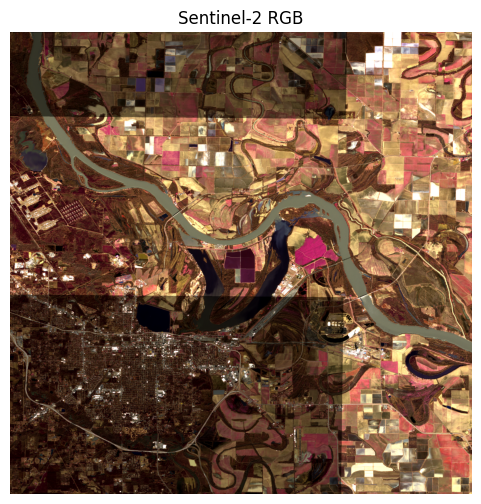

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Lire bandes
red   = sentinel_arkansas.read(4)
green = sentinel_arkansas.read(3)
blue  = sentinel_arkansas.read(2)

rgb = np.stack((red, green, blue), axis=-1).astype(float)

# Normalisation (contrast stretch)
p2, p98 = np.percentile(rgb, (2, 98))
rgb = (rgb - p2) / (p98 - p2 + 1e-6)
rgb = np.clip(rgb, 0, 1)

# Affichage
plt.figure(figsize=(6,6))
plt.imshow(rgb)
plt.title("Sentinel-2 RGB")
plt.axis('off')
plt.show()

Shape: (4164, 3464)
Min value: 0
Max value: 190
Unique classes (first 20): [  0   1   2   3   5  24  26  59  61 111 121 122 123 124 142 176 190]


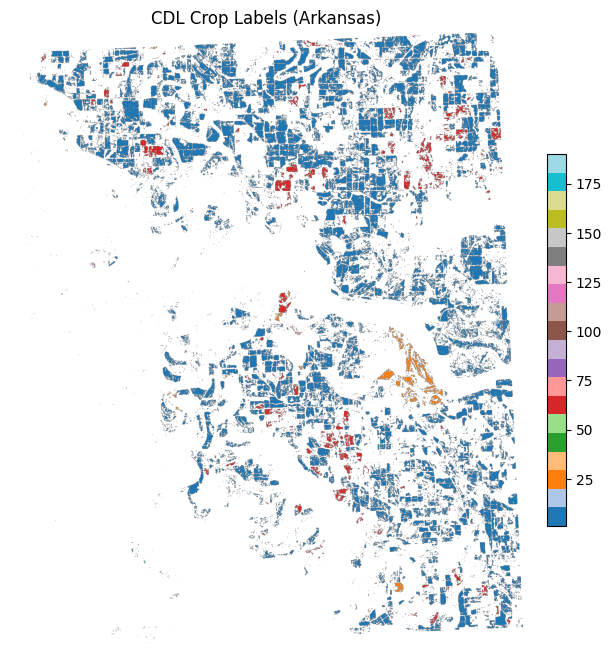

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt


cdl_arkansas = rasterio.open(dataset_path + "/CDL_2021_Labels_Arkansas.tif")

labels = cdl_arkansas.read(1)


print("Shape:", labels.shape)
print("Min value:", np.min(labels))
print("Max value:", np.max(labels))
print("Unique classes (first 20):", np.unique(labels)[:20])

# -------------------------------
# Clean data (remove background)
# -------------------------------
labels_clean = np.where(labels == 0, np.nan, labels)

plt.figure(figsize=(8, 8))
img = plt.imshow(labels_clean, cmap='tab20')
plt.title("CDL Crop Labels (Arkansas)")
plt.colorbar(img, fraction=0.03, pad=0.04)
plt.axis('off')
plt.show()


In [ ]:
#compute NVDI

red = sentinel_arkansas.read(4).astype("float32")
nir = sentinel_arkansas.read(8).astype("float32")

ndvi = (nir - red) / (nir + red + 1e-6)

print(ndvi.min(), ndvi.max())

-1.0 1.0


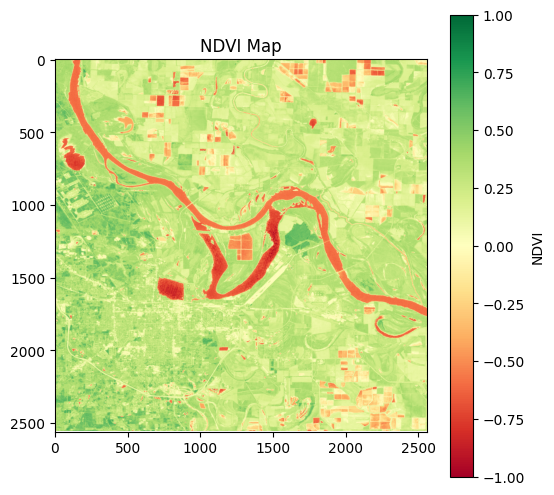

In [ ]:
#plot NVDI

plt.figure(figsize=(6,6))

plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)

plt.title("NDVI Map")
plt.colorbar(label="NDVI")

plt.show()

In [ ]:
#arkansas crops
crops = {
    "Corn":1,
    "Rice":3,
    "Soybeans":5,
    "Cotton":2
}

In [ ]:
#it handles a mismatch in map projections and the reprojection

from rasterio.crs import CRS
from rasterio.warp import calculate_default_transform, reproject, Resampling

# 1. Manually define the "Missing" info for the CDL
# Most CDL products use EPSG:5070 (Albers Equal Area)
cdl_crs = CRS.from_epsg(5070)

# 2. We need the original dimensions of the CDL file
src_height, src_width = cdl_data.shape

# 3. Calculate the correct transform based on the state-wide extent
# Note: If you don't have the bounds, we have to 'guess' or find them in the dataset metadata.
# Let's try to project the CDL data into the Sentinel's space properly:
reproject(
    source=cdl_data,
    destination=labels_resampled,
    src_transform=cdl_arkansas.transform, # Use its native (even if it's 1.0)
    src_crs=cdl_crs,             # The 'guessed' CRS
    dst_transform=sentinel_arkansas.transform,
    dst_crs=sentinel_arkansas.crs,
    resampling=Resampling.nearest
)

labels = labels_resampled

In [ ]:
import numpy as np

# 1. Check the raw data values
cdl_data = cdl_arkansas.read(1)
print(f"CDL Data Shape: {cdl_data.shape}")
print(f"Unique values in CDL: {np.unique(cdl_data)}")

# 2. Check the Sentinel metadata
print(f"Sentinel Transform: {sentinel_arkansas.transform}")
print(f"Sentinel CRS: {sentinel_arkansas.crs}")

CDL Data Shape: (4164, 3464)
Unique values in CDL: [  0   1   2   3   5  24  26  59  61 111 121 122 123 124 142 176 190]
Sentinel Transform: | 0.00, 0.00,-92.08|
| 0.00,-0.00, 34.38|
| 0.00, 0.00, 1.00|
Sentinel CRS: EPSG:4326


In [ ]:
import cv2 # Using OpenCV for a fast, simple resize
import numpy as np

# 1. Read the CDL raw data
cdl_data = cdl_arkansas.read(1)

# 2. Get the target dimensions from the Sentinel file
target_height = sentinel_arkansas.height
target_width = sentinel_arkansas.width

# 3. Use INTER_NEAREST to keep the crop labels (numbers) exact
# We resize the CDL array to match the Sentinel array perfectly
labels_aligned = cv2.resize(
    cdl_data,
    (target_width, target_height),
    interpolation=cv2.INTER_NEAREST
)

labels = labels_aligned
print(f"New label shape: {labels.shape}")

New label shape: (2560, 2560)


In [ ]:
from rasterio.warp import reproject, Resampling

sentinel = sentinel_arkansas
cdl = cdl_arkansas

sentinel_shape = (sentinel.height, sentinel.width)

labels_resampled = np.empty(sentinel_shape, dtype=cdl.dtypes[0])

reproject(
    source=rasterio.band(cdl, 1),
    destination=labels_resampled,
    src_transform=cdl.transform,
    src_crs=cdl.crs,
    dst_transform=sentinel.transform,
    dst_crs=sentinel.crs,
    resampling=Resampling.nearest
)

labels = labels_resampled

In [ ]:
ndvi_curves = {crop:[] for crop in crops}

for crop, cid in crops.items():

    mask = labels == cid
    ndvi_mean = np.nanmean(ndvi[mask])

    ndvi_curves[crop].append(ndvi_mean)

In [ ]:
import numpy as np

# 1. Read the Sentinel data into a NumPy array
# Assuming bands are stacked: [B1_t1, B2_t1... B1_t2, B2_t2...]
# Or if it's a pre-calculated NDVI cube:
sentinel_data = sentinel_arkansas.read() # This creates a (Bands, Height, Width) array

# 2. Define your crop codes (adjust based on your actual unique values)
crop_codes = {"Corn": 1, "Cotton": 2, "Rice": 3, "Soybean": 5}
ndvi_curves = {}

# 3. The Loop
# Note: Check if your 'sentinel_data' is already NDVI or raw bands
for crop_name, code in crop_codes.items():
    mask = (labels == code)

    if not np.any(mask):
        print(f"No pixels found for {crop_name}")
        continue

    crop_means = []
    # Loop through the first dimension (the time steps/bands)
    for t in range(sentinel_data.shape[0]):
        time_step_layer = sentinel_data[t]

        # Calculate mean of pixels where the mask is True
        mean_val = np.mean(time_step_layer[mask])
        crop_means.append(mean_val)

    ndvi_curves[crop_name] = crop_means

print("Curves calculated!")

Curves calculated!


# **3/24/26**

In [ ]:
import os

# ===============================
# EXPLORE WHAT'S IN THE DATASET
# ===============================
for root, dirs, files in os.walk(dataset_path):
    # Skip hidden folders
    dirs[:] = [d for d in dirs if not d.startswith('.')]
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for file in files:
        filepath = os.path.join(root, file)
        size_mb = os.path.getsize(filepath) / (1024 * 1024)
        print(f'{subindent}{file}  ({size_mb:.1f} MB)')

3a2f3e2448069a6f4b502a735aa6bb7be50e73d5/
  arkansas.TIF  (0.1 MB)
  Sentinel2_2021_36steps_Arkansas-0000002560-0000002560.tif  (1177.3 MB)
  Sentinel2_2021_36steps_California-0000002560-0000000000.tif  (2242.6 MB)
  CDL_2021_Labels_Arkansas.tif  (0.6 MB)
  CDL_2021_Labels_California.tif  (0.7 MB)
  california.TIF  (0.0 MB)
  Sentinel2_2021_36steps_Arkansas-0000002560-0000000000.tif  (1451.9 MB)
  .gitattributes  (0.0 MB)
  Sentinel2_2021_36steps_California-0000002560-0000002560.tif  (1262.5 MB)
  Sentinel2_2021_36steps_California-0000000000-0000000000.tif  (3879.5 MB)
  Sentinel2_2021_36steps_California-0000000000-0000002560.tif  (2244.2 MB)
  Sentinel2_2021_36steps_Arkansas-0000000000-0000000000.tif  (2655.4 MB)
  Sentinel2_2021_36steps_Arkansas-0000000000-0000002560.tif  (1877.4 MB)


In [ ]:
import os
import numpy as np
import rasterio
from rasterio.transform import rowcol
from rasterio.crs import CRS
import random

# ===============================
# 1. DEFINE FILE PATHS
# ===============================
ark_tiles = sorted([
    os.path.join(dataset_path, f)
    for f in os.listdir(dataset_path)
    if 'Sentinel2_2021_36steps_Arkansas' in f and f.endswith('.tif')
])

cdl_ark_path = os.path.join(dataset_path, 'CDL_2021_Labels_Arkansas.tif')

print("Arkansas tiles:")
for t in ark_tiles:
    print(" ", os.path.basename(t))

# ===============================
# 2. OPEN ALL TILES + GET BOUNDS
# ===============================
# We'll keep tiles open and query each one
tile_srcs = [rasterio.open(t) for t in ark_tiles]

# Print info about each tile
for i, src in enumerate(tile_srcs):
    print(f"\nTile {i}: {os.path.basename(ark_tiles[i])}")
    print(f"  Shape: {src.count} bands, {src.height}x{src.width}")
    print(f"  CRS: {src.crs}")
    print(f"  Bounds: {src.bounds}")

Arkansas tiles:
  Sentinel2_2021_36steps_Arkansas-0000000000-0000000000.tif
  Sentinel2_2021_36steps_Arkansas-0000000000-0000002560.tif
  Sentinel2_2021_36steps_Arkansas-0000002560-0000000000.tif
  Sentinel2_2021_36steps_Arkansas-0000002560-0000002560.tif

Tile 0: Sentinel2_2021_36steps_Arkansas-0000000000-0000000000.tif
  Shape: 360 bands, 2560x2560
  CRS: EPSG:4326
  Bounds: BoundingBox(left=-92.08001156810332, bottom=34.15017417803091, right=-91.85004285536871, top=34.380142890765505)

Tile 1: Sentinel2_2021_36steps_Arkansas-0000000000-0000002560.tif
  Shape: 360 bands, 2560x1448
  CRS: EPSG:4326
  Bounds: BoundingBox(left=-91.85004285536871, bottom=34.15017417803091, right=-91.7199668022282, top=34.380142890765505)

Tile 2: Sentinel2_2021_36steps_Arkansas-0000002560-0000000000.tif
  Shape: 360 bands, 1450x2560
  CRS: EPSG:4326
  Bounds: BoundingBox(left=-92.08001156810332, bottom=34.019918461833576, right=-91.85004285536871, top=34.15017417803091)

Tile 3: Sentinel2_2021_36steps_Ar

In [ ]:
import rasterio
import os

# Check CDL bounds and CRS
cdl_src = rasterio.open(cdl_ark_path)
print("CDL CRS:", cdl_src.crs)
print("CDL bounds:", cdl_src.bounds)
print("CDL shape:", cdl_src.height, cdl_src.width)
print("CDL dtype:", cdl_src.dtypes)

# Check a few actual pixel values
import numpy as np
sample_data = cdl_src.read(1)
print("\nCDL unique values (first 20):", np.unique(sample_data)[:20])
print("CDL non-zero pixels:", (sample_data > 0).sum())
print("CDL zero pixels:", (sample_data == 0).sum())

# Check Sentinel tile 0
print("\n--- Sentinel Tile 0 ---")
s_src = rasterio.open(ark_tiles[0])
print("Sentinel CRS:", s_src.crs)
print("Sentinel bounds:", s_src.bounds)

# Check if bounds overlap
print("\n--- Overlap Check ---")
print(f"CDL lon range:      [{cdl_src.bounds.left:.4f}, {cdl_src.bounds.right:.4f}]")
print(f"Sentinel lon range: [{s_src.bounds.left:.4f}, {s_src.bounds.right:.4f}]")
print(f"CDL lat range:      [{cdl_src.bounds.bottom:.4f}, {cdl_src.bounds.top:.4f}]")
print(f"Sentinel lat range: [{s_src.bounds.bottom:.4f}, {s_src.bounds.top:.4f}]")

cdl_src.close()
s_src.close()

CDL CRS: EPSG:5070
CDL bounds: BoundingBox(left=357585.0, bottom=1224615.0, right=392225.0, top=1266255.0)
CDL shape: 4164 3464
CDL dtype: ('uint16',)

CDL unique values (first 20): [  0   1   2   3   5  24  26  59  61 111 121 122 123 124 142 176 190]
CDL non-zero pixels: 1902578
CDL zero pixels: 12521518

--- Sentinel Tile 0 ---
Sentinel CRS: EPSG:4326
Sentinel bounds: BoundingBox(left=-92.08001156810332, bottom=34.15017417803091, right=-91.85004285536871, top=34.380142890765505)

--- Overlap Check ---
CDL lon range:      [357585.0000, 392225.0000]
Sentinel lon range: [-92.0800, -91.8500]
CDL lat range:      [1224615.0000, 1266255.0000]
Sentinel lat range: [34.1502, 34.3801]


In [ ]:
for root, dirs, files in os.walk("/"):
    for f in files:
        if 'Sentinel2_2021_36steps_Arkansas' in f:
            print(os.path.join(root, f))
            break

/root/.cache/huggingface/hub/datasets--inessal--CropMappingSentinel2/snapshots/3a2f3e2448069a6f4b502a735aa6bb7be50e73d5/Sentinel2_2021_36steps_Arkansas-0000002560-0000002560.tif


In [ ]:
import numpy as np
import rasterio
from rasterio.transform import rowcol
from pyproj import Transformer
import os
from collections import defaultdict

# 1. SETUP
dataset_path = "/root/.cache/huggingface/hub/datasets--inessal--CropMappingSentinel2/snapshots/3a2f3e2448069a6f4b502a735aa6bb7be50e73d5"

ark_tiles = sorted([
    os.path.join(dataset_path, f)
    for f in os.listdir(dataset_path)
    if 'Sentinel2_2021_36steps_Arkansas' in f and f.endswith('.tif')
])
cdl_ark_path = os.path.join(dataset_path, 'CDL_2021_Labels_Arkansas.tif')

# Open datasets
tile_srcs = [rasterio.open(t) for t in ark_tiles]
cdl_src   = rasterio.open(cdl_ark_path)

# 2. COORDINATE TRANSFORMERS
t_to_cdl = Transformer.from_crs("EPSG:4326", "EPSG:5070", always_xy=True)
t_to_wgs = Transformer.from_crs("EPSG:5070", "EPSG:4326", always_xy=True)

# 3. TILE INDEX (optional speed-up)
tile_index = []
for src in tile_srcs:
    b = src.bounds
    tile_index.append({'src': src, 'left': b.left, 'right': b.right, 'bottom': b.bottom, 'top': b.top})

# 4. HELPER FUNCTIONS
def get_tile_for_point(lon, lat):
    for t in tile_index:
        if t['left'] <= lon <= t['right'] and t['bottom'] <= lat <= t['top']:
            return t['src']
    return None

def read_pixel(src, lon, lat):
    try:
        row, col = rowcol(src.transform, lon, lat)
        if 0 <= row < src.height and 0 <= col < src.width:
            window = rasterio.windows.Window(col, row, 1, 1)
            pixel  = src.read(window=window)  # (360,1,1)
            return pixel.reshape(360)
    except:
        return None
    return None

def read_cdl_pixel(x, y):
    try:
        row, col = rowcol(cdl_src.transform, x, y)
        if 0 <= row < cdl_src.height and 0 <= col < cdl_src.width:
            window = rasterio.windows.Window(col, row, 1, 1)
            pixel  = cdl_src.read(1, window=window)
            return int(pixel[0, 0])
    except:
        return None
    return None

# 5. SAMPLING
N_SAMPLES   = 10000
MAX_TRIES   = 500000
RANDOM_SEED = 42
CHUNK_PRINT = 500
np.random.seed(RANDOM_SEED)

VALID_CLASSES = {1: 'Corn', 2: 'Cotton', 3: 'Rice', 5: 'Soybeans'}

samples_X    = []
samples_mask = []
samples_y    = []
class_counts = defaultdict(int)

cdl_bounds = cdl_src.bounds
print(f"CDL bounds (EPSG:5070): {cdl_bounds}")

tries = 0
print("\nSampling points...")
while len(samples_X) < N_SAMPLES and tries < MAX_TRIES:
    tries += 1

    # Sample a point in CDL space
    x = np.random.uniform(cdl_bounds.left,   cdl_bounds.right)
    y = np.random.uniform(cdl_bounds.bottom, cdl_bounds.top)

    # Read CDL
    label = read_cdl_pixel(x, y)
    if label is None or label == 0:
        continue

    mapped_label = label if label in VALID_CLASSES else 99

    # Convert to WGS84 for Sentinel
    lon, lat = t_to_wgs.transform(x, y)

    # Read Sentinel pixel
    tile = get_tile_for_point(lon, lat)
    if tile is None:
        continue

    spectral = read_pixel(tile, lon, lat)
    if spectral is None:
        continue

    # Missing mask
    spectral_2d = spectral.reshape(36, 10).astype(np.float32)
    missing     = (spectral_2d.sum(axis=1) == 0).astype(np.float32)

    samples_X.append(spectral_2d.reshape(360))
    samples_mask.append(missing)
    samples_y.append(mapped_label)
    class_counts[mapped_label] += 1

    if len(samples_X) % CHUNK_PRINT == 0:
        print(f"  {len(samples_X)}/{N_SAMPLES} | tries: {tries} | {dict(class_counts)}")

print(f"\nDone! {len(samples_X)} samples in {tries} tries")
label_names = {1:'Corn', 2:'Cotton', 3:'Rice', 5:'Soybeans', 99:'Others'}
for k, v in sorted(class_counts.items()):
    print(f"  {label_names.get(k, k)}: {v}")

# 6. SAVE
X    = np.array(samples_X,    dtype=np.float32)
mask = np.array(samples_mask, dtype=np.float32)
y    = np.array(samples_y,    dtype=np.int32)

print(f"\nX shape:    {X.shape}")
print(f"mask shape: {mask.shape}")
print(f"y shape:    {y.shape}")

save_dir = os.path.join(dataset_path, 'processed')
os.makedirs(save_dir, exist_ok=True)
np.save(os.path.join(save_dir, 'Arkansas_X.npy'),    X)
np.save(os.path.join(save_dir, 'Arkansas_mask.npy'), mask)
np.save(os.path.join(save_dir, 'Arkansas_y.npy'),    y)
print(f"Saved to {save_dir}")

# Close all datasets
for src in tile_srcs:
    src.close()
cdl_src.close()

CDL bounds (EPSG:5070): BoundingBox(left=357585.0, bottom=1224615.0, right=392225.0, top=1266255.0)

Sampling points...
  500/10000 | tries: 3751 | {5: 160, 1: 132, 3: 126, 2: 31, 99: 51}
  1000/10000 | tries: 7608 | {5: 317, 1: 283, 3: 233, 2: 60, 99: 107}
  1500/10000 | tries: 11386 | {5: 475, 1: 428, 3: 348, 2: 100, 99: 149}
  2000/10000 | tries: 15378 | {5: 623, 1: 567, 3: 470, 2: 137, 99: 203}
  2500/10000 | tries: 19043 | {5: 787, 1: 726, 3: 577, 2: 169, 99: 241}
  3000/10000 | tries: 22587 | {5: 940, 1: 874, 3: 688, 2: 209, 99: 289}
  3500/10000 | tries: 26411 | {5: 1098, 1: 1016, 3: 809, 2: 245, 99: 332}
  4000/10000 | tries: 30321 | {5: 1254, 1: 1140, 3: 941, 2: 284, 99: 381}
  4500/10000 | tries: 34230 | {5: 1414, 1: 1289, 3: 1053, 2: 324, 99: 420}
  5000/10000 | tries: 37713 | {5: 1569, 1: 1417, 3: 1180, 2: 359, 99: 475}
  5500/10000 | tries: 41701 | {5: 1733, 1: 1573, 3: 1284, 2: 388, 99: 522}
  6000/10000 | tries: 45651 | {5: 1886, 1: 1709, 3: 1395, 2: 426, 99: 584}
  6500

In [ ]:
import numpy as np
import os
from huggingface_hub import snapshot_download


X_path    = os.path.join(dataset_path, "Arkansas_X .npy")
mask_path = os.path.join(dataset_path, "Arkansas_mask.npy")
y_path    = os.path.join(dataset_path, "Arkansas_y.npy")

# Chargement
X    = np.load(X_path)
mask = np.load(mask_path)
y    = np.load(y_path)

print("\nShapes:")
print("X:", X.shape)
print("mask:", mask.shape)
print("y:", y.shape)


Shapes:
X: (10000, 360)
mask: (10000, 36)
y: (10000,)


In [ ]:
X = X.reshape(-1, 36, 10)

In [ ]:
nir = X[:, :, 6]
red = X[:, :, 2]

ndvi = (nir - red) / (nir + red + 1e-6)

In [ ]:
mean_ndvi = {}

for c in np.unique(y):
    class_data = ndvi[y == c]

    # Mask zeros
    mask_nonzero = class_data != 0

    # Sum only valid values
    sum_vals = np.sum(class_data * mask_nonzero, axis=0)

    # Count valid values
    count_vals = np.sum(mask_nonzero, axis=0)

    # Avoid division by zero
    mean_curve = np.divide(
        sum_vals,
        count_vals,
        out=np.zeros_like(sum_vals),
        where=count_vals != 0
    )

    mean_ndvi[c] = mean_curve

/tmp/ipykernel_9666/1428701917.py:41: RuntimeWarning: Mean of empty slice
  mean_ndvi = np.nanmean(ndvi_cls, axis=0)  # (36,)


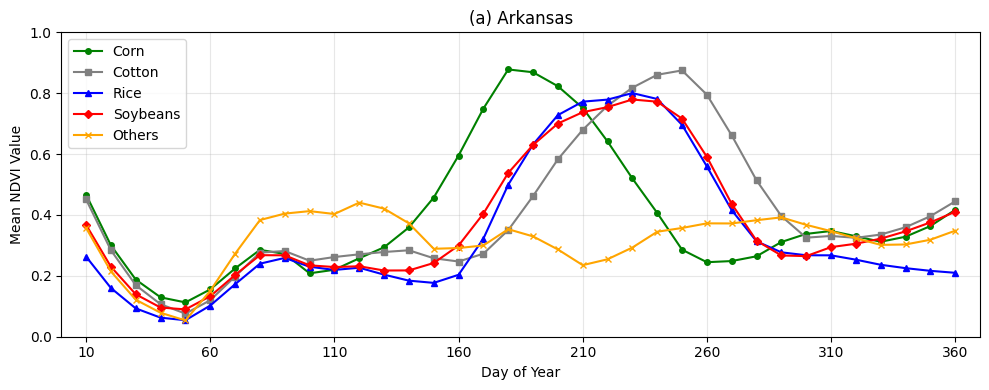

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# 1. RESHAPE + COMPUTE NDVI
X_3d = X.reshape(10000, 36, 10)

B4 = X_3d[:, :, 2].astype(np.float32)
B8 = X_3d[:, :, 6].astype(np.float32)

denom = B4 + B8
denom[denom == 0] = np.nan
NDVI  = (B8 - B4) / denom  # (10000, 36)

# 2. MASK ALL INVALID VALUES
NDVI_plot = NDVI.copy()
NDVI_plot[mask == 1] = np.nan        # missing timesteps
NDVI_plot[np.isnan(denom)] = np.nan  # zero bands
NDVI_plot[NDVI_plot < 0] = np.nan    # negative NDVI (invalid for crops)
NDVI_plot[NDVI_plot > 1] = np.nan    # above 1 (invalid)

# 3. PLOT
doy       = np.arange(1, 37) * 10
label_map = {1: 'Corn', 2: 'Cotton', 3: 'Rice', 5: 'Soybeans', 99: 'Others'}
colors    = {1: 'green', 2: 'gray',  3: 'blue', 5: 'red',      99: 'orange'}
markers   = {1: 'o',    2: 's',      3: '^',    5: 'D',        99: 'x'}

fig, ax = plt.subplots(figsize=(10, 4))

for cls in [1, 2, 3, 5, 99]:
    idx      = (y == cls)
    ndvi_cls = NDVI_plot[idx]  # (n_samples, 36)

    # Mean ignoring NaN
    mean_ndvi = np.nanmean(ndvi_cls, axis=0)  # (36,)

    # Interpolate NaNs using valid neighbors
    nans  = np.isnan(mean_ndvi)
    x_idx = np.arange(36)
    if nans.sum() < 36:  # at least some valid points
        mean_ndvi[nans] = np.interp(
            x_idx[nans],
            x_idx[~nans],
            mean_ndvi[~nans]
        )

    # Clip to valid NDVI range AFTER interpolation
    mean_ndvi = np.clip(mean_ndvi, 0, 1)

    # Smooth
    mean_ndvi = savgol_filter(mean_ndvi, window_length=7, polyorder=2)

    # Clip again after smoothing (smoothing can push slightly below 0)
    mean_ndvi = np.clip(mean_ndvi, 0, 1)

    ax.plot(doy, mean_ndvi,
            label=label_map[cls],
            color=colors[cls],
            marker=markers[cls],
            markersize=4,
            linewidth=1.5)

ax.set_xlabel('Day of Year')
ax.set_ylabel('Mean NDVI Value')
ax.set_title('(a) Arkansas')
ax.legend(loc='upper left')
ax.set_ylim(0, 1)
ax.set_xlim(0, 370)
ax.set_xticks([10, 60, 110, 160, 210, 260, 310, 360])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
from huggingface_hub import snapshot_download
import os
import numpy as np

# 1. LOAD ARKANSAS FILES

X = np.load(os.path.join(dataset_path, "Arkansas_X .npy"))
y = np.load(os.path.join(dataset_path, "Arkansas_y.npy"))
mask = np.load(os.path.join(dataset_path, "Arkansas_mask.npy"))

print("\n✅ Shapes:")
print("X:", X.shape)
print("y:", y.shape)
print("mask:", mask.shape)

# 2. COUNT SAMPLES PER CLASS
unique, counts = np.unique(y, return_counts=True)

print("\n Samples per class:\n")
for u, c in zip(unique, counts):
    print(f"Class {u}: {c}")

# 3. MAP CLASSES → CROPS
label_map = {
    1: "Corn ",
    2: "Cotton",
    3: "Rice ",
    5: "Soybeans",
    99: "Others "
}

print("\n Class meaning:\n")
for u, c in zip(unique, counts):
    name = label_map.get(u, "Unknown")
    print(f"Class {u} ({name}): {c}")

# 5. TOTAL CHECK
print("\n Total samples:", len(y))

if len(y) == 10000:
    print(" Total matches paper (10000)")
else:
    print(" Total is incorrect")

# 6. MASK QUALITY CHECK
missing = np.sum(mask == 0)
valid = np.sum(mask == 1)

print("\n Mask stats:")
print("Missing values:", missing)
print("Valid values:", valid)

ratio = valid / (valid + missing)
print(f"Valid ratio: {ratio:.2f}")


✅ Shapes:
X: (10000, 360)
y: (10000,)
mask: (10000, 36)

 Samples per class:

Class 1: 1522
Class 2: 762
Class 3: 2423
Class 5: 4677
Class 99: 616

 Class meaning:

Class 1 (Corn ): 1522
Class 2 (Cotton): 762
Class 3 (Rice ): 2423
Class 5 (Soybeans): 4677
Class 99 (Others ): 616

 Total samples: 10000
 Total matches paper (10000)

 Mask stats:
Missing values: 247929
Valid values: 112071
Valid ratio: 0.31


**CALIFORNIA**

In [1]:
from huggingface_hub import snapshot_download
import os

dataset_path = snapshot_download(
    repo_id="inessal/CropMappingSentinel2",
    repo_type="dataset"
)
print("Current dataset path:", dataset_path)
print("\nFiles available:")
for f in os.listdir(dataset_path):
    print(" ", f)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 32 files:   0%|          | 0/32 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
unique, counts = np.unique(y_all, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Class {u}: {c}")

Class 3: 2037
Class 36: 974
Class 69: 22316
Class 75: 1922
Class 99: 5262
Class 204: 500


In [ ]:
def inspect_labels(path):
    import numpy as np
    y = np.load(path)
    unique, counts = np.unique(y, return_counts=True)

    print(f"\nFile: {path}")
    for u, c in zip(unique, counts):
        print(f"  Class {u}: {c}")

# Example
inspect_labels("/content/drive/MyDrive/Fresno_y.npy")
inspect_labels("/content/drive/MyDrive/California_Fresno_y.npy")
inspect_labels("/content/drive/MyDrive/Sacramento_y.npy")


File: /content/drive/MyDrive/Fresno_y.npy
  Class 69: 22316
  Class 75: 1922
  Class 99: 5262
  Class 204: 640

File: /content/drive/MyDrive/California_Fresno_y.npy
  Class 69: 22316
  Class 75: 1922
  Class 99: 5262
  Class 204: 500

File: /content/drive/MyDrive/Sacramento_y.npy
  Class 3: 2037
  Class 36: 974


In [ ]:
import numpy as np
import os

# 1. LOAD FILES FROM DRIVE
base_path = "/content/drive/MyDrive"

X_fresno = np.load(os.path.join(base_path, "Fresno_X.npy"))
mask_fresno = np.load(os.path.join(base_path, "Fresno_mask.npy"))
y_fresno = np.load(os.path.join(base_path, "Fresno_y.npy"))

X_sac = np.load(os.path.join(base_path, "Sacramento_X.npy"))
mask_sac = np.load(os.path.join(base_path, "Sacramento_mask.npy"))
y_sac = np.load(os.path.join(base_path, "Sacramento_y.npy"))

# 2. MERGE EVERYTHING
X_all = np.concatenate([X_fresno, X_sac], axis=0)
mask_all = np.concatenate([mask_fresno, mask_sac], axis=0)
y_all = np.concatenate([y_fresno, y_sac], axis=0)

print("Merged shape:", X_all.shape)

# 3. TARGET DISTRIBUTION
target_counts = {
    69: 2054,   # Grapes
    3: 2037,    # Rice
    36: 974,    # Alfalfa
    75: 783,    # Almonds
    204: 640,   # Pistachios
    99: 3512    # Others
}

# 4. RESAMPLE TO MATCH PAPER
X_final = []
mask_final = []
y_final = []

np.random.seed(42)

for cls, n_samples in target_counts.items():
    idx = np.where(y_all == cls)[0]

    if len(idx) < n_samples:
        print(f"⚠️ Not enough samples for class {cls}, using all available")
        chosen = idx
    else:
        chosen = np.random.choice(idx, n_samples, replace=False)

    X_final.append(X_all[chosen])
    mask_final.append(mask_all[chosen])
    y_final.append(y_all[chosen])

# 5. CONCAT FINAL DATASET
X_final = np.concatenate(X_final, axis=0)
mask_final = np.concatenate(mask_final, axis=0)
y_final = np.concatenate(y_final, axis=0)

print("Final shape:", X_final.shape)

# 6. SHUFFLE
perm = np.random.permutation(len(X_final))

X_final = X_final[perm]
mask_final = mask_final[perm]
y_final = y_final[perm]

# 7. SAVE
save_path = os.path.join(base_path, "California")

os.makedirs(save_path, exist_ok=True)

np.save(os.path.join(save_path, "California_X.npy"), X_final)
np.save(os.path.join(save_path, "California_mask.npy"), mask_final)
np.save(os.path.join(save_path, "California_y.npy"), y_final)

print("✅ Saved California dataset!")

Merged shape: (33151, 360)
Final shape: (10000, 360)
✅ Saved California dataset!


In [ ]:
print("dataset_path:", dataset_path)

# Verify all 4 key files are found
import os
fresno_tiles = sorted([f for f in os.listdir(dataset_path)
                       if 'Sentinel2_2021_36steps_California-' in f and f.endswith('.tif')])
sac_tiles    = sorted([f for f in os.listdir(dataset_path)
                       if 'Sentinel2_2021_36steps_California_Sacramento' in f and f.endswith('.tif')])

print(f"\nFresno tiles ({len(fresno_tiles)}):")
for f in fresno_tiles: print(" ", f)

print(f"\nSacramento tiles ({len(sac_tiles)}):")
for f in sac_tiles: print(" ", f)

In [ ]:
import numpy as np
import rasterio
from rasterio.transform import rowcol
from pyproj import Transformer
import os
from collections import defaultdict
from huggingface_hub import snapshot_download

dataset_path = snapshot_download(repo_id="inessal/CropMappingSentinel2", repo_type="dataset")
save_dir     = os.path.join(dataset_path, 'processed')
os.makedirs(save_dir, exist_ok=True)

label_names = {69:'Grapes', 75:'Almonds', 204:'Pistachios',
               3:'Rice',    36:'Alfalfa',  99:'Others'}

def build_tile_index(tiles):
    srcs = [rasterio.open(t) for t in tiles]
    index = []
    for src in srcs:
        b = src.bounds
        index.append({'src': src, 'left': b.left, 'right': b.right,
                      'bottom': b.bottom, 'top': b.top})
    return srcs, index

def get_tile_for_point(lon, lat, tile_index):
    for t in tile_index:
        if t['left'] <= lon <= t['right'] and t['bottom'] <= lat <= t['top']:
            return t['src']
    return None

def read_pixel(src, lon, lat):
    try:
        row, col = rowcol(src.transform, lon, lat)
        if 0 <= row < src.height and 0 <= col < src.width:
            window = rasterio.windows.Window(col, row, 1, 1)
            return src.read(window=window).reshape(360)
    except:
        return None
    return None

def read_cdl_pixel(cdl_src, x, y):
    try:
        row, col = rowcol(cdl_src.transform, x, y)
        if 0 <= row < cdl_src.height and 0 <= col < cdl_src.width:
            window = rasterio.windows.Window(col, row, 1, 1)
            return int(cdl_src.read(1, window=window)[0, 0])
    except:
        return None
    return None

def sample_area(sentinel_tiles, cdl_path, valid_classes,
                n_samples, max_tries=2000000, seed=42):
    t_to_wgs   = Transformer.from_crs("EPSG:5070", "EPSG:4326", always_xy=True)
    tile_srcs, tile_index = build_tile_index(sentinel_tiles)
    cdl_src    = rasterio.open(cdl_path)
    cdl_bounds = cdl_src.bounds

    np.random.seed(seed)
    samples_X, samples_mask, samples_y = [], [], []
    class_counts = defaultdict(int)
    tries = 0

    while len(samples_X) < n_samples and tries < max_tries:
        tries += 1
        x = np.random.uniform(cdl_bounds.left,  cdl_bounds.right)
        y = np.random.uniform(cdl_bounds.bottom, cdl_bounds.top)

        label = read_cdl_pixel(cdl_src, x, y)
        if label is None or label == 0:
            continue

        mapped_label = label if label in valid_classes else 99
        lon, lat     = t_to_wgs.transform(x, y)
        tile         = get_tile_for_point(lon, lat, tile_index)
        if tile is None:
            continue

        spectral = read_pixel(tile, lon, lat)
        if spectral is None:
            continue

        spectral_2d = spectral.reshape(36, 10).astype(np.float32)
        missing     = (spectral_2d.sum(axis=1) == 0).astype(np.float32)

        samples_X.append(spectral_2d.reshape(360))
        samples_mask.append(missing)
        samples_y.append(mapped_label)
        class_counts[mapped_label] += 1

        if len(samples_X) % 500 == 0:
            print(f"  {len(samples_X)}/{n_samples} | tries: {tries} | {dict(class_counts)}")

    for src in tile_srcs:
        src.close()
    cdl_src.close()

    return (np.array(samples_X,    dtype=np.float32),
            np.array(samples_mask, dtype=np.float32),
            np.array(samples_y,    dtype=np.int32),
            class_counts)

def safe_sample(idx, n):
    return np.random.choice(idx, min(n, len(idx)), replace=False)

print("Setup done ✓")

Fetching 21 files:   0%|          | 0/21 [00:00<?, ?it/s]

Setup done ✓


In [ ]:
fresno_tiles = sorted([
    os.path.join(dataset_path, f)
    for f in os.listdir(dataset_path)
    if 'Sentinel2_2021_36steps_California-' in f and f.endswith('.tif')
])
cdl_fresno = os.path.join(dataset_path, 'CDL_2021_Labels_California.tif')
print(f"Found {len(fresno_tiles)} Fresno tiles\n")

print("=== Sampling Fresno ===")
X_fresno, mask_fresno, y_fresno, counts_fresno = sample_area(
    sentinel_tiles = fresno_tiles,
    cdl_path       = cdl_fresno,
    valid_classes  = {69: 'Grapes', 75: 'Almonds', 204: 'Pistachios'},
    n_samples      = 30000,
    max_tries      = 15000000,
    seed           = 42
)

print("\nFresno RAW distribution:")
for k, v in sorted(counts_fresno.items()):
    print(f"  {label_names.get(k, k)}: {v}")

# Balance
np.random.seed(42)
idx_g = safe_sample(np.where(y_fresno == 69)[0],  2054)
idx_a = safe_sample(np.where(y_fresno == 75)[0],  783)
idx_p = safe_sample(np.where(y_fresno == 204)[0], 640)
idx_o = safe_sample(np.where(y_fresno == 99)[0],  500)

keep = np.concatenate([idx_g, idx_a, idx_p, idx_o])
np.random.shuffle(keep)

X_fresno_bal    = X_fresno[keep]
mask_fresno_bal = mask_fresno[keep]
y_fresno_bal    = y_fresno[keep]

print("\nFresno BALANCED distribution:")
unique, counts = np.unique(y_fresno_bal, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {label_names.get(int(u), u)}: {c}")

np.save(os.path.join(save_dir, 'Fresno_X.npy'),    X_fresno_bal)
np.save(os.path.join(save_dir, 'Fresno_mask.npy'), mask_fresno_bal)
np.save(os.path.join(save_dir, 'Fresno_y.npy'),    y_fresno_bal)
print("\nFresno saved ✓  — paste RAW distribution here before running Cell 3")

Found 4 Fresno tiles

=== Sampling Fresno ===
  500/30000 | tries: 6026 | {69: 372, 75: 32, 99: 86, 204: 10}
  1000/30000 | tries: 11977 | {69: 743, 75: 58, 99: 186, 204: 13}
  1500/30000 | tries: 17657 | {69: 1109, 75: 92, 99: 276, 204: 23}
  2000/30000 | tries: 23146 | {69: 1479, 75: 122, 99: 371, 204: 28}
  2500/30000 | tries: 28984 | {69: 1855, 75: 154, 99: 457, 204: 34}
  3000/30000 | tries: 34945 | {69: 2229, 75: 186, 99: 541, 204: 44}
  3500/30000 | tries: 41029 | {69: 2609, 75: 218, 99: 623, 204: 50}
  4000/30000 | tries: 46983 | {69: 2975, 75: 245, 99: 717, 204: 63}
  4500/30000 | tries: 52806 | {69: 3345, 75: 275, 99: 808, 204: 72}
  5000/30000 | tries: 58639 | {69: 3710, 75: 306, 99: 899, 204: 85}
  5500/30000 | tries: 64282 | {69: 4081, 75: 340, 99: 987, 204: 92}
  6000/30000 | tries: 70660 | {69: 4441, 75: 377, 99: 1082, 204: 100}
  6500/30000 | tries: 76825 | {69: 4816, 75: 407, 99: 1170, 204: 107}
  7000/30000 | tries: 83255 | {69: 5203, 75: 434, 99: 1252, 204: 111}
  75

In [ ]:
import numpy as np
import rasterio
from rasterio.transform import rowcol
from pyproj import Transformer
import os
from collections import defaultdict
from google.colab import drive

# 1. MOUNT GOOGLE DRIVE
drive.mount('/content/drive')

# 2. FIND TULARE FILES
tulare_dir = '/content/drive/MyDrive/GEE_exports'

tulare_tiles = sorted([
    os.path.join(tulare_dir, f)
    for f in os.listdir(tulare_dir)
    if 'Sentinel2_2021_36steps_California_Tulare' in f and f.endswith('.tif')
])
cdl_tulare = os.path.join(tulare_dir, 'CDL_2021_Labels_California_Tulare.tif')

print("Tulare Sentinel tiles:")
for t in tulare_tiles:
    print(" ", os.path.basename(t))
print("\nCDL:", os.path.basename(cdl_tulare))

# Check CDL
cdl_src = rasterio.open(cdl_tulare)
print("\nCDL CRS:", cdl_src.crs)
print("CDL bounds:", cdl_src.bounds)
import numpy as np
data = cdl_src.read(1)
unique, counts = np.unique(data, return_counts=True)
print("\nPixel counts:")
for u, c in zip(unique, counts):
    if c > 100:
        print(f"  Class {u}: {c} pixels")
cdl_src.close()

Mounted at /content/drive
Tulare Sentinel tiles:
  Sentinel2_2021_36steps_California_Tulare-0000000000-0000000000.tif
  Sentinel2_2021_36steps_California_Tulare-0000000000-0000002560.tif
  Sentinel2_2021_36steps_California_Tulare-0000002560-0000000000.tif
  Sentinel2_2021_36steps_California_Tulare-0000002560-0000002560.tif

CDL: CDL_2021_Labels_California_Tulare.tif

CDL CRS: EPSG:5070
CDL bounds: BoundingBox(left=-2078605.0, bottom=1680055.0, right=-2037655.0, top=1726975.0)

Pixel counts:
  Class 0: 17323523 pixels
  Class 1: 191219 pixels
  Class 2: 68405 pixels
  Class 4: 819 pixels
  Class 23: 675 pixels
  Class 24: 85173 pixels
  Class 28: 2025 pixels
  Class 36: 289165 pixels
  Class 54: 2838 pixels
  Class 61: 1037 pixels
  Class 66: 18303 pixels
  Class 69: 314829 pixels
  Class 71: 7088 pixels
  Class 72: 14179 pixels
  Class 75: 248757 pixels
  Class 76: 102139 pixels
  Class 121: 58067 pixels
  Class 122: 21848 pixels
  Class 123: 5837 pixels
  Class 124: 1039 pixels
  Clas

In [ ]:
import numpy as np
import rasterio
from rasterio.transform import rowcol
from pyproj import Transformer
import os
from collections import defaultdict

# SETUP — adjust paths if needed
tulare_dir = '/content/drive/MyDrive/GEE_exports'

tulare_tiles = sorted([
    os.path.join(tulare_dir, f)
    for f in os.listdir(tulare_dir)
    if 'Sentinel2_2021_36steps_California_Tulare' in f and f.endswith('.tif')
])
cdl_tulare = os.path.join(tulare_dir, 'CDL_2021_Labels_California_Tulare.tif')

print(f"Found {len(tulare_tiles)} Tulare tiles")
print(f"CDL: {cdl_tulare}\n")

# HELPER FUNCTIONS
def build_tile_index(tiles):
    srcs = [rasterio.open(t) for t in tiles]
    index = []
    for src in srcs:
        b = src.bounds
        index.append({'src': src, 'left': b.left, 'right': b.right,
                      'bottom': b.bottom, 'top': b.top})
    return srcs, index

def get_tile_for_point(lon, lat, tile_index):
    for t in tile_index:
        if t['left'] <= lon <= t['right'] and t['bottom'] <= lat <= t['top']:
            return t['src']
    return None

def read_pixel(src, lon, lat):
    try:
        row, col = rowcol(src.transform, lon, lat)
        if 0 <= row < src.height and 0 <= col < src.width:
            window = rasterio.windows.Window(col, row, 1, 1)
            return src.read(window=window).reshape(360)
    except:
        return None
    return None

def read_cdl_pixel(cdl_src, x, y):
    try:
        row, col = rowcol(cdl_src.transform, x, y)
        if 0 <= row < cdl_src.height and 0 <= col < cdl_src.width:
            window = rasterio.windows.Window(col, row, 1, 1)
            return int(cdl_src.read(1, window=window)[0, 0])
    except:
        return None
    return None

# PISTACHIO-ONLY SAMPLING
def sample_pistachios(sentinel_tiles, cdl_path,
                      n_samples=800, max_tries=5000000, seed=99):

    t_to_wgs   = Transformer.from_crs("EPSG:5070", "EPSG:4326", always_xy=True)
    tile_srcs, tile_index = build_tile_index(sentinel_tiles)
    cdl_src    = rasterio.open(cdl_path)
    cdl_bounds = cdl_src.bounds

    np.random.seed(seed)
    samples_X, samples_mask, samples_y = [], [], []
    tries = 0

    while len(samples_X) < n_samples and tries < max_tries:
        tries += 1
        x = np.random.uniform(cdl_bounds.left,  cdl_bounds.right)
        y = np.random.uniform(cdl_bounds.bottom, cdl_bounds.top)

        label = read_cdl_pixel(cdl_src, x, y)

        # Only accept pistachios (class 204)
        if label != 204:
            continue

        lon, lat = t_to_wgs.transform(x, y)
        tile     = get_tile_for_point(lon, lat, tile_index)
        if tile is None:
            continue

        spectral = read_pixel(tile, lon, lat)
        if spectral is None:
            continue

        spectral_2d = spectral.reshape(36, 10).astype(np.float32)
        missing     = (spectral_2d.sum(axis=1) == 0).astype(np.float32)

        samples_X.append(spectral_2d.reshape(360))
        samples_mask.append(missing)
        samples_y.append(204)

        if len(samples_X) % 100 == 0:
            print(f"  Pistachios: {len(samples_X)}/{n_samples} | tries: {tries}")

    for src in tile_srcs:
        src.close()
    cdl_src.close()

    print(f"\nDone — collected {len(samples_X)} pistachio samples in {tries} tries")

    return (np.array(samples_X,    dtype=np.float32),
            np.array(samples_mask, dtype=np.float32),
            np.array(samples_y,    dtype=np.int32))

# RUN
print("=== Sampling Pistachios from Tulare ===")
X_pist, mask_pist, y_pist = sample_pistachios(
    sentinel_tiles = tulare_tiles,
    cdl_path       = cdl_tulare,
    n_samples      = 800,        # asking for 800 to have margin, we'll trim to 640 after
    max_tries      = 5000000,
    seed           = 99
)

print(f"\nShape: {X_pist.shape}")
print(f"All labels are 204: {np.all(y_pist == 204)}")

# SAVE
save_dir = '/content/drive/MyDrive/'  # adjust to your save location
np.save(os.path.join(save_dir, 'Tulare_pistachios_X.npy'),    X_pist)
np.save(os.path.join(save_dir, 'Tulare_pistachios_mask.npy'), mask_pist)
np.save(os.path.join(save_dir, 'Tulare_pistachios_y.npy'),    y_pist)
print("Tulare pistachios saved ✓")

Found 4 Tulare tiles
CDL: /content/drive/MyDrive/GEE_exports/CDL_2021_Labels_California_Tulare.tif

=== Sampling Pistachios from Tulare ===
  Pistachios: 100/800 | tries: 10022
  Pistachios: 200/800 | tries: 18571
  Pistachios: 300/800 | tries: 27987
  Pistachios: 400/800 | tries: 35365
  Pistachios: 500/800 | tries: 43527
  Pistachios: 600/800 | tries: 51906
  Pistachios: 700/800 | tries: 61432
  Pistachios: 800/800 | tries: 70793

Done — collected 800 pistachio samples in 70793 tries

Shape: (800, 360)
All labels are 204: True
Tulare pistachios saved ✓


In [ ]:
import numpy as np
import os

save_dir = '/content/drive/MyDrive'  # adjust to your save location

# LOAD EXISTING FRESNO
X_fresno    = np.load(os.path.join(save_dir, 'California_Fresno_X.npy'))
mask_fresno = np.load(os.path.join(save_dir, 'California_Fresno_mask.npy'))
y_fresno    = np.load(os.path.join(save_dir, 'California_Fresno_y.npy'))

print("Fresno BEFORE replacement:")
label_names = {69:'Grapes', 75:'Almonds', 204:'Pistachios', 99:'Others'}
unique, counts = np.unique(y_fresno, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {label_names.get(int(u), u)}: {c}")

# LOAD TULARE PISTACHIOS
X_pist    = np.load(os.path.join(save_dir, 'Tulare_pistachios_X.npy'))
mask_pist = np.load(os.path.join(save_dir, 'Tulare_pistachios_mask.npy'))
y_pist    = np.load(os.path.join(save_dir, 'Tulare_pistachios_y.npy'))

# Trim to exactly 640
np.random.seed(42)
idx        = np.random.choice(len(X_pist), 640, replace=False)
X_pist     = X_pist[idx]
mask_pist  = mask_pist[idx]
y_pist     = y_pist[idx]

print(f"\nTulare pistachios loaded: {len(X_pist)} samples")

# REMOVE OLD PISTACHIOS FROM FRESNO
keep        = (y_fresno != 204)
X_fresno    = X_fresno[keep]
mask_fresno = mask_fresno[keep]
y_fresno    = y_fresno[keep]

print(f"\nFresno after removing old pistachios: {X_fresno.shape}")

# ADD TULARE PISTACHIOS
X_fresno    = np.concatenate([X_fresno,    X_pist])
mask_fresno = np.concatenate([mask_fresno, mask_pist])
y_fresno    = np.concatenate([y_fresno,    y_pist])

# Shuffle
np.random.seed(42)
idx         = np.random.permutation(len(X_fresno))
X_fresno    = X_fresno[idx]
mask_fresno = mask_fresno[idx]
y_fresno    = y_fresno[idx]

print("\nFresno AFTER replacement:")
unique, counts = np.unique(y_fresno, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {label_names.get(int(u), u)}: {c}")

# OVERWRITE FRESNO FILES
np.save(os.path.join(save_dir, 'Fresno_X.npy'),    X_fresno)
np.save(os.path.join(save_dir, 'Fresno_mask.npy'), mask_fresno)
np.save(os.path.join(save_dir, 'Fresno_y.npy'),    y_fresno)
print("\nFresno_X.npy overwritten with correct pistachios ✓")

Fresno BEFORE replacement:
  Grapes: 22316
  Almonds: 1922
  Others: 5262
  Pistachios: 500

Tulare pistachios loaded: 640 samples

Fresno after removing old pistachios: (29500, 360)

Fresno AFTER replacement:
  Grapes: 22316
  Almonds: 1922
  Others: 5262
  Pistachios: 640

Fresno_X.npy overwritten with correct pistachios ✓


In [ ]:
import numpy as np

X = np.load(os.path.join(save_dir, 'Fresno_X.npy'))
print(X.shape)

(30140, 360)


In [ ]:
from huggingface_hub import snapshot_download
import numpy as np
import rasterio
from rasterio.transform import rowcol
from pyproj import Transformer
import os
from collections import defaultdict
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt

# 1. DATASET PATH
dataset_path = snapshot_download(repo_id="inessal/CropMappingSentinel2", repo_type="dataset")
save_dir     = os.path.join(dataset_path, 'processed')
os.makedirs(save_dir, exist_ok=True)

label_names = {69:'Grapes', 75:'Almonds', 204:'Pistachios',
               3:'Rice',    36:'Alfalfa',  99:'Others'}

# 2. HELPER FUNCTIONS
def build_tile_index(tiles):
    srcs = [rasterio.open(t) for t in tiles]
    index = []
    for src in srcs:
        b = src.bounds
        index.append({'src': src, 'left': b.left, 'right': b.right,
                      'bottom': b.bottom, 'top': b.top})
    return srcs, index

def get_tile_for_point(lon, lat, tile_index):
    for t in tile_index:
        if t['left'] <= lon <= t['right'] and t['bottom'] <= lat <= t['top']:
            return t['src']
    return None

def read_pixel(src, lon, lat):
    try:
        row, col = rowcol(src.transform, lon, lat)
        if 0 <= row < src.height and 0 <= col < src.width:
            window = rasterio.windows.Window(col, row, 1, 1)
            return src.read(window=window).reshape(360)
    except:
        return None
    return None

def read_cdl_pixel(cdl_src, x, y):
    try:
        row, col = rowcol(cdl_src.transform, x, y)
        if 0 <= row < cdl_src.height and 0 <= col < cdl_src.width:
            window = rasterio.windows.Window(col, row, 1, 1)
            return int(cdl_src.read(1, window=window)[0, 0])
    except:
        return None
    return None

def sample_area(sentinel_tiles, cdl_path, valid_classes,
                n_samples, max_tries=2000000, seed=42):
    t_to_wgs   = Transformer.from_crs("EPSG:5070", "EPSG:4326", always_xy=True)
    tile_srcs, tile_index = build_tile_index(sentinel_tiles)
    cdl_src    = rasterio.open(cdl_path)
    cdl_bounds = cdl_src.bounds

    np.random.seed(seed)
    samples_X, samples_mask, samples_y = [], [], []
    class_counts = defaultdict(int)
    tries = 0

    while len(samples_X) < n_samples and tries < max_tries:
        tries += 1
        x = np.random.uniform(cdl_bounds.left,  cdl_bounds.right)
        y = np.random.uniform(cdl_bounds.bottom, cdl_bounds.top)

        label = read_cdl_pixel(cdl_src, x, y)
        if label is None or label == 0:
            continue

        mapped_label = label if label in valid_classes else 99
        lon, lat     = t_to_wgs.transform(x, y)
        tile         = get_tile_for_point(lon, lat, tile_index)
        if tile is None:
            continue

        spectral = read_pixel(tile, lon, lat)
        if spectral is None:
            continue

        spectral_2d = spectral.reshape(36, 10).astype(np.float32)
        missing     = (spectral_2d.sum(axis=1) == 0).astype(np.float32)

        samples_X.append(spectral_2d.reshape(360))
        samples_mask.append(missing)
        samples_y.append(mapped_label)
        class_counts[mapped_label] += 1

        if len(samples_X) % 500 == 0:
            print(f"  {len(samples_X)}/{n_samples} | tries: {tries} | {dict(class_counts)}")

    for src in tile_srcs:
        src.close()
    cdl_src.close()

    return (np.array(samples_X,    dtype=np.float32),
            np.array(samples_mask, dtype=np.float32),
            np.array(samples_y,    dtype=np.int32),
            class_counts)

# 3. FRESNO TILES + CDL
fresno_tiles = sorted([
    os.path.join(dataset_path, f)
    for f in os.listdir(dataset_path)
    if 'Sentinel2_2021_36steps_California-' in f and f.endswith('.tif')
])
cdl_fresno = os.path.join(dataset_path, 'CDL_2021_Labels_California.tif')

# 4. SACRAMENTO TILES + CDL
sacramento_tiles = sorted([
    os.path.join(dataset_path, f)
    for f in os.listdir(dataset_path)
    if 'Sentinel2_2021_36steps_California_Sacramento' in f and f.endswith('.tif')
])
cdl_sacramento = os.path.join(dataset_path, 'CDL_2021_Labels_California_Sacramento.tif')

# 5. SAMPLE FRESNO (6000 points)
print("=== Sampling Fresno ===")
X_fresno, mask_fresno, y_fresno, counts_fresno = sample_area(
    sentinel_tiles = fresno_tiles,
    cdl_path       = cdl_fresno,
    valid_classes  = {69: 'Grapes', 75: 'Almonds', 204: 'Pistachios'},
    n_samples      = 6000,
    seed           = 42
)
print("\nFresno raw distribution:")
for k, v in sorted(counts_fresno.items()):
    print(f"  {label_names.get(k, k)}: {v}")

# 6. SAMPLE SACRAMENTO (4000, Rice+Alfalfa ONLY)
print("\n=== Sampling Sacramento (Rice + Alfalfa only) ===")
X_sac, mask_sac, y_sac, counts_sac = sample_area(
    sentinel_tiles = sacramento_tiles,
    cdl_path       = cdl_sacramento,
    valid_classes  = {3: 'Rice', 36: 'Alfalfa'},
    n_samples      = 4000,
    max_tries      = 2000000,
    seed           = 123
)

# Drop Others from Sacramento
keep      = (y_sac != 99)
X_sac     = X_sac[keep]
mask_sac  = mask_sac[keep]
y_sac     = y_sac[keep]

print("\nSacramento filtered distribution:")
unique, counts = np.unique(y_sac, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {label_names.get(int(u), u)}: {c}")

# 7. BALANCE FRESNO
# Cap Grapes at 2500, Others at 500
np.random.seed(42)
idx_grapes  = np.where(y_fresno == 69)[0]
idx_almonds = np.where(y_fresno == 75)[0]
idx_pist    = np.where(y_fresno == 204)[0]
idx_others  = np.where(y_fresno == 99)[0]

idx_grapes_keep = np.random.choice(idx_grapes, min(2500, len(idx_grapes)), replace=False)
idx_others_keep = np.random.choice(idx_others, min(500,  len(idx_others)), replace=False)

keep_fresno  = np.concatenate([idx_grapes_keep, idx_almonds, idx_pist, idx_others_keep])
X_fresno     = X_fresno[keep_fresno]
mask_fresno  = mask_fresno[keep_fresno]
y_fresno     = y_fresno[keep_fresno]

print("\nFresno balanced distribution:")
unique, counts = np.unique(y_fresno, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {label_names.get(int(u), u)}: {c}")

# 8. MERGE + SHUFFLE
X_cal    = np.concatenate([X_fresno,    X_sac],    axis=0)
mask_cal = np.concatenate([mask_fresno, mask_sac], axis=0)
y_cal    = np.concatenate([y_fresno,    y_sac],    axis=0)

idx      = np.random.permutation(len(X_cal))
X_cal    = X_cal[idx]
mask_cal = mask_cal[idx]
y_cal    = y_cal[idx]

print(f"\nFinal shape: {X_cal.shape}")
print("Final California class distribution:")
unique, counts = np.unique(y_cal, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {label_names.get(int(u), u)}: {c}")

# 9. SAVE
np.save(os.path.join(save_dir, 'California_X.npy'),    X_cal)
np.save(os.path.join(save_dir, 'California_mask.npy'), mask_cal)
np.save(os.path.join(save_dir, 'California_y.npy'),    y_cal)
print(f"\nSaved to {save_dir}")



In [ ]:
from huggingface_hub import snapshot_download
import numpy as np
import rasterio
from rasterio.transform import rowcol
from pyproj import Transformer
import os
from collections import defaultdict
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt

# 1. DATASET PATH
dataset_path = snapshot_download(repo_id="inessal/CropMappingSentinel2", repo_type="dataset")
save_dir     = os.path.join(dataset_path, 'processed')
os.makedirs(save_dir, exist_ok=True)

label_names = {69:'Grapes', 75:'Almonds', 204:'Pistachios',
               3:'Rice',    36:'Alfalfa',  99:'Others'}

# 2. HELPER FUNCTIONS
def build_tile_index(tiles):
    srcs = [rasterio.open(t) for t in tiles]
    index = []
    for src in srcs:
        b = src.bounds
        index.append({'src': src, 'left': b.left, 'right': b.right,
                      'bottom': b.bottom, 'top': b.top})
    return srcs, index

def get_tile_for_point(lon, lat, tile_index):
    for t in tile_index:
        if t['left'] <= lon <= t['right'] and t['bottom'] <= lat <= t['top']:
            return t['src']
    return None

def read_pixel(src, lon, lat):
    try:
        row, col = rowcol(src.transform, lon, lat)
        if 0 <= row < src.height and 0 <= col < src.width:
            window = rasterio.windows.Window(col, row, 1, 1)
            return src.read(window=window).reshape(360)
    except:
        return None
    return None

def read_cdl_pixel(cdl_src, x, y):
    try:
        row, col = rowcol(cdl_src.transform, x, y)
        if 0 <= row < cdl_src.height and 0 <= col < cdl_src.width:
            window = rasterio.windows.Window(col, row, 1, 1)
            return int(cdl_src.read(1, window=window)[0, 0])
    except:
        return None
    return None

def sample_area(sentinel_tiles, cdl_path, valid_classes,
                n_samples, max_tries=2000000, seed=42):
    t_to_wgs   = Transformer.from_crs("EPSG:5070", "EPSG:4326", always_xy=True)
    tile_srcs, tile_index = build_tile_index(sentinel_tiles)
    cdl_src    = rasterio.open(cdl_path)
    cdl_bounds = cdl_src.bounds

    np.random.seed(seed)
    samples_X, samples_mask, samples_y = [], [], []
    class_counts = defaultdict(int)
    tries = 0

    while len(samples_X) < n_samples and tries < max_tries:
        tries += 1
        x = np.random.uniform(cdl_bounds.left,  cdl_bounds.right)
        y = np.random.uniform(cdl_bounds.bottom, cdl_bounds.top)

        label = read_cdl_pixel(cdl_src, x, y)
        if label is None or label == 0:
            continue

        mapped_label = label if label in valid_classes else 99
        lon, lat     = t_to_wgs.transform(x, y)
        tile         = get_tile_for_point(lon, lat, tile_index)
        if tile is None:
            continue

        spectral = read_pixel(tile, lon, lat)
        if spectral is None:
            continue

        spectral_2d = spectral.reshape(36, 10).astype(np.float32)
        missing     = (spectral_2d.sum(axis=1) == 0).astype(np.float32)

        samples_X.append(spectral_2d.reshape(360))
        samples_mask.append(missing)
        samples_y.append(mapped_label)
        class_counts[mapped_label] += 1

        if len(samples_X) % 500 == 0:
            print(f"  {len(samples_X)}/{n_samples} | tries: {tries} | {dict(class_counts)}")

    for src in tile_srcs:
        src.close()
    cdl_src.close()

    return (np.array(samples_X,    dtype=np.float32),
            np.array(samples_mask, dtype=np.float32),
            np.array(samples_y,    dtype=np.int32),
            class_counts)

# 3. FRESNO TILES + CDL
fresno_tiles = sorted([
    os.path.join(dataset_path, f)
    for f in os.listdir(dataset_path)
    if 'Sentinel2_2021_36steps_California-' in f and f.endswith('.tif')
])
cdl_fresno = os.path.join(dataset_path, 'CDL_2021_Labels_California.tif')

# 4. SACRAMENTO TILES + CDL
sacramento_tiles = sorted([
    os.path.join(dataset_path, f)
    for f in os.listdir(dataset_path)
    if 'Sentinel2_2021_36steps_California_Sacramento' in f and f.endswith('.tif')
])
cdl_sacramento = os.path.join(dataset_path, 'CDL_2021_Labels_California_Sacramento.tif')

# 5. SAMPLE FRESNO (6000 points)
print("=== Sampling Fresno ===")
X_fresno, mask_fresno, y_fresno, counts_fresno = sample_area(
    sentinel_tiles = fresno_tiles,
    cdl_path       = cdl_fresno,
    valid_classes  = {69: 'Grapes', 75: 'Almonds', 204: 'Pistachios'},
    n_samples      = 6000,
    seed           = 42
)
print("\nFresno raw distribution:")
for k, v in sorted(counts_fresno.items()):
    print(f"  {label_names.get(k, k)}: {v}")

# 6. SAMPLE SACRAMENTO (4000, Rice+Alfalfa ONLY)
print("\n=== Sampling Sacramento (Rice + Alfalfa only) ===")
X_sac, mask_sac, y_sac, counts_sac = sample_area(
    sentinel_tiles = sacramento_tiles,
    cdl_path       = cdl_sacramento,
    valid_classes  = {3: 'Rice', 36: 'Alfalfa'},
    n_samples      = 4000,
    max_tries      = 2000000,
    seed           = 123
)

# Drop Others from Sacramento
keep      = (y_sac != 99)
X_sac     = X_sac[keep]
mask_sac  = mask_sac[keep]
y_sac     = y_sac[keep]

print("\nSacramento filtered distribution:")
unique, counts = np.unique(y_sac, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {label_names.get(int(u), u)}: {c}")

# 7. BALANCE FRESNO
# Cap Grapes at 2500, Others at 500
np.random.seed(42)
idx_grapes  = np.where(y_fresno == 69)[0]
idx_almonds = np.where(y_fresno == 75)[0]
idx_pist    = np.where(y_fresno == 204)[0]
idx_others  = np.where(y_fresno == 99)[0]

idx_grapes_keep = np.random.choice(idx_grapes, min(2500, len(idx_grapes)), replace=False)
idx_others_keep = np.random.choice(idx_others, min(500,  len(idx_others)), replace=False)

keep_fresno  = np.concatenate([idx_grapes_keep, idx_almonds, idx_pist, idx_others_keep])
X_fresno     = X_fresno[keep_fresno]
mask_fresno  = mask_fresno[keep_fresno]
y_fresno     = y_fresno[keep_fresno]

print("\nFresno balanced distribution:")
unique, counts = np.unique(y_fresno, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {label_names.get(int(u), u)}: {c}")

# 8. MERGE + SHUFFLE
X_cal    = np.concatenate([X_fresno,    X_sac],    axis=0)
mask_cal = np.concatenate([mask_fresno, mask_sac], axis=0)
y_cal    = np.concatenate([y_fresno,    y_sac],    axis=0)

idx      = np.random.permutation(len(X_cal))
X_cal    = X_cal[idx]
mask_cal = mask_cal[idx]
y_cal    = y_cal[idx]

print(f"\nFinal shape: {X_cal.shape}")
print("Final California class distribution:")
unique, counts = np.unique(y_cal, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {label_names.get(int(u), u)}: {c}")

# 9. SAVE
np.save(os.path.join(save_dir, 'California_X.npy'),    X_cal)
np.save(os.path.join(save_dir, 'California_mask.npy'), mask_cal)
np.save(os.path.join(save_dir, 'California_y.npy'),    y_cal)
print(f"\nSaved to {save_dir}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 21 files:   0%|          | 0/21 [00:00<?, ?it/s]

=== Sampling Fresno ===
  500/6000 | tries: 6026 | {69: 372, 75: 32, 99: 86, 204: 10}
  1000/6000 | tries: 11977 | {69: 743, 75: 58, 99: 186, 204: 13}
  1500/6000 | tries: 17657 | {69: 1109, 75: 92, 99: 276, 204: 23}
  2000/6000 | tries: 23146 | {69: 1479, 75: 122, 99: 371, 204: 28}
  2500/6000 | tries: 28984 | {69: 1855, 75: 154, 99: 457, 204: 34}
  3000/6000 | tries: 34945 | {69: 2229, 75: 186, 99: 541, 204: 44}
  3500/6000 | tries: 41029 | {69: 2609, 75: 218, 99: 623, 204: 50}
  4000/6000 | tries: 46983 | {69: 2975, 75: 245, 99: 717, 204: 63}
  4500/6000 | tries: 52806 | {69: 3345, 75: 275, 99: 808, 204: 72}
  5000/6000 | tries: 58639 | {69: 3710, 75: 306, 99: 899, 204: 85}
  5500/6000 | tries: 64282 | {69: 4081, 75: 340, 99: 987, 204: 92}
  6000/6000 | tries: 70660 | {69: 4441, 75: 377, 99: 1082, 204: 100}

Fresno raw distribution:
  Grapes: 4441
  Almonds: 377
  Others: 1082
  Pistachios: 100

=== Sampling Sacramento (Rice + Alfalfa only) ===
  500/4000 | tries: 5388 | {99: 390, 3

Different approach

In [ ]:
import numpy as np
import rasterio
from rasterio.transform import rowcol
from pyproj import Transformer
import os
from collections import defaultdict
from huggingface_hub import snapshot_download

dataset_path = snapshot_download(repo_id="inessal/CropMappingSentinel2", repo_type="dataset")
save_dir     = os.path.join(dataset_path, 'processed')
os.makedirs(save_dir, exist_ok=True)

label_names = {69:'Grapes', 75:'Almonds', 204:'Pistachios',
               3:'Rice',    36:'Alfalfa',  99:'Others'}

def build_tile_index(tiles):
    srcs = [rasterio.open(t) for t in tiles]
    index = []
    for src in srcs:
        b = src.bounds
        index.append({'src': src, 'left': b.left, 'right': b.right,
                      'bottom': b.bottom, 'top': b.top})
    return srcs, index

def get_tile_for_point(lon, lat, tile_index):
    for t in tile_index:
        if t['left'] <= lon <= t['right'] and t['bottom'] <= lat <= t['top']:
            return t['src']
    return None

def read_pixel(src, lon, lat):
    try:
        row, col = rowcol(src.transform, lon, lat)
        if 0 <= row < src.height and 0 <= col < src.width:
            window = rasterio.windows.Window(col, row, 1, 1)
            return src.read(window=window).reshape(360)
    except:
        return None
    return None

def read_cdl_pixel(cdl_src, x, y):
    try:
        row, col = rowcol(cdl_src.transform, x, y)
        if 0 <= row < cdl_src.height and 0 <= col < cdl_src.width:
            window = rasterio.windows.Window(col, row, 1, 1)
            return int(cdl_src.read(1, window=window)[0, 0])
    except:
        return None
    return None

def sample_area(sentinel_tiles, cdl_path, valid_classes,
                n_samples, max_tries=2000000, seed=42):
    t_to_wgs   = Transformer.from_crs("EPSG:5070", "EPSG:4326", always_xy=True)
    tile_srcs, tile_index = build_tile_index(sentinel_tiles)
    cdl_src    = rasterio.open(cdl_path)
    cdl_bounds = cdl_src.bounds

    np.random.seed(seed)
    samples_X, samples_mask, samples_y = [], [], []
    class_counts = defaultdict(int)
    tries = 0

    while len(samples_X) < n_samples and tries < max_tries:
        tries += 1
        x = np.random.uniform(cdl_bounds.left,  cdl_bounds.right)
        y = np.random.uniform(cdl_bounds.bottom, cdl_bounds.top)

        label = read_cdl_pixel(cdl_src, x, y)
        if label is None or label == 0:
            continue

        mapped_label = label if label in valid_classes else 99
        lon, lat     = t_to_wgs.transform(x, y)
        tile         = get_tile_for_point(lon, lat, tile_index)
        if tile is None:
            continue

        spectral = read_pixel(tile, lon, lat)
        if spectral is None:
            continue

        spectral_2d = spectral.reshape(36, 10).astype(np.float32)
        missing     = (spectral_2d.sum(axis=1) == 0).astype(np.float32)

        samples_X.append(spectral_2d.reshape(360))
        samples_mask.append(missing)
        samples_y.append(mapped_label)
        class_counts[mapped_label] += 1

        if len(samples_X) % 500 == 0:
            print(f"  {len(samples_X)}/{n_samples} | tries: {tries} | {dict(class_counts)}")

    for src in tile_srcs:
        src.close()
    cdl_src.close()

    return (np.array(samples_X,    dtype=np.float32),
            np.array(samples_mask, dtype=np.float32),
            np.array(samples_y,    dtype=np.int32),
            class_counts)

def safe_sample(idx, n):
    return np.random.choice(idx, min(n, len(idx)), replace=False)

print("Setup done ✓")

Fetching 21 files:   0%|          | 0/21 [00:00<?, ?it/s]

Setup done ✓


In [ ]:
fresno_tiles = sorted([
    os.path.join(dataset_path, f)
    for f in os.listdir(dataset_path)
    if 'Sentinel2_2021_36steps_California-' in f and f.endswith('.tif')
])
cdl_fresno = os.path.join(dataset_path, 'CDL_2021_Labels_California.tif')
print(f"Found {len(fresno_tiles)} Fresno tiles\n")

print("=== Sampling Fresno ===")
X_fresno, mask_fresno, y_fresno, counts_fresno = sample_area(
    sentinel_tiles = fresno_tiles,
    cdl_path       = cdl_fresno,
    valid_classes  = {69: 'Grapes', 75: 'Almonds', 204: 'Pistachios'},
    n_samples      = 30000,
    max_tries      = 15000000,
    seed           = 42
)

print("\nFresno RAW distribution:")
for k, v in sorted(counts_fresno.items()):
    print(f"  {label_names.get(k, k)}: {v}")

# Balance
np.random.seed(42)
idx_g = safe_sample(np.where(y_fresno == 69)[0],  2054)
idx_a = safe_sample(np.where(y_fresno == 75)[0],  783)
idx_p = safe_sample(np.where(y_fresno == 204)[0], 640)
idx_o = safe_sample(np.where(y_fresno == 99)[0],  500)

keep = np.concatenate([idx_g, idx_a, idx_p, idx_o])
np.random.shuffle(keep)

X_fresno_bal    = X_fresno[keep]
mask_fresno_bal = mask_fresno[keep]
y_fresno_bal    = y_fresno[keep]

print("\nFresno BALANCED distribution:")
unique, counts = np.unique(y_fresno_bal, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {label_names.get(int(u), u)}: {c}")

np.save(os.path.join(save_dir, 'Fresno_X.npy'),    X_fresno_bal)
np.save(os.path.join(save_dir, 'Fresno_mask.npy'), mask_fresno_bal)
np.save(os.path.join(save_dir, 'Fresno_y.npy'),    y_fresno_bal)
print("\nFresno saved ✓  — paste RAW distribution here before running Cell 3")

Found 4 Fresno tiles

=== Sampling Fresno ===
  500/30000 | tries: 6026 | {69: 372, 75: 32, 99: 86, 204: 10}
  1000/30000 | tries: 11977 | {69: 743, 75: 58, 99: 186, 204: 13}
  1500/30000 | tries: 17657 | {69: 1109, 75: 92, 99: 276, 204: 23}
  2000/30000 | tries: 23146 | {69: 1479, 75: 122, 99: 371, 204: 28}
  2500/30000 | tries: 28984 | {69: 1855, 75: 154, 99: 457, 204: 34}
  3000/30000 | tries: 34945 | {69: 2229, 75: 186, 99: 541, 204: 44}
  3500/30000 | tries: 41029 | {69: 2609, 75: 218, 99: 623, 204: 50}
  4000/30000 | tries: 46983 | {69: 2975, 75: 245, 99: 717, 204: 63}
  4500/30000 | tries: 52806 | {69: 3345, 75: 275, 99: 808, 204: 72}
  5000/30000 | tries: 58639 | {69: 3710, 75: 306, 99: 899, 204: 85}
  5500/30000 | tries: 64282 | {69: 4081, 75: 340, 99: 987, 204: 92}
  6000/30000 | tries: 70660 | {69: 4441, 75: 377, 99: 1082, 204: 100}
  6500/30000 | tries: 76830 | {69: 4815, 75: 407, 99: 1171, 204: 107}
  7000/30000 | tries: 83269 | {69: 5203, 75: 434, 99: 1252, 204: 111}
  75

/tmp/ipykernel_8146/1296751700.py:73: RuntimeWarning: Mean of empty slice
  mean_ndvi = np.nanmean(ndvi_cls, axis=0)


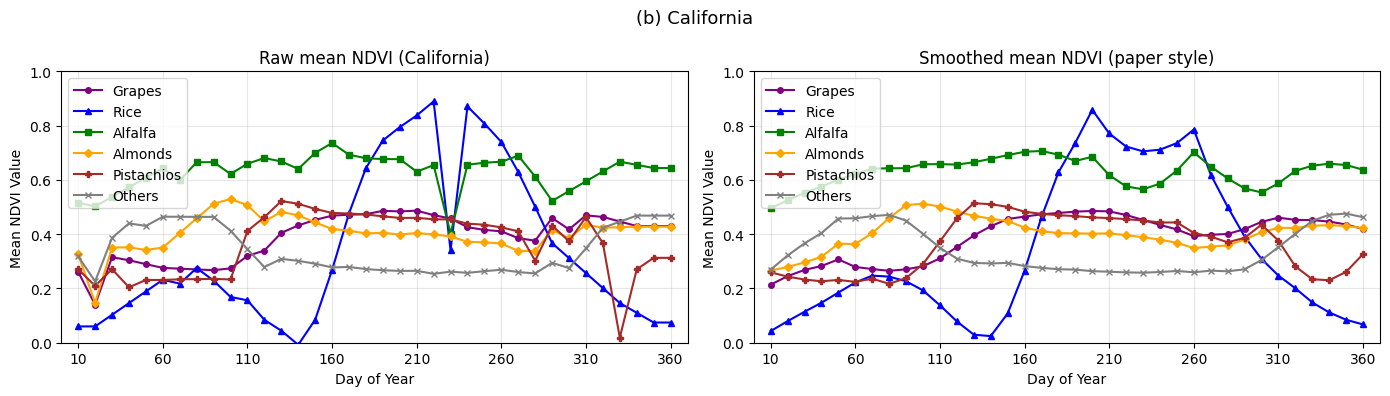

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# 1. RESHAPE + COMPUTE NDVI
X_3d = X.reshape(10000, 36, 10)

B4 = X_3d[:, :, 2].astype(np.float32)   # RED
B8 = X_3d[:, :, 6].astype(np.float32)   # NIR

denom = B4 + B8
denom[denom == 0] = np.nan
NDVI  = (B8 - B4) / denom

# 2. MASK missing timesteps
NDVI_plot = NDVI.copy()
NDVI_plot[mask == 1] = np.nan
NDVI_plot[np.isnan(denom)] = np.nan

# 3. CALIFORNIA SETTINGS
doy = np.arange(1, 37) * 10

label_map = {
    69: 'Grapes',
    3: 'Rice',
    36: 'Alfalfa',
    75: 'Almonds',
    204: 'Pistachios',
    99: 'Others'
}

colors = {
    69: 'purple',
    3: 'blue',
    36: 'green',
    75: 'orange',
    204: 'brown',
    99: 'gray'
}

markers = {
    69: 'o',
    3: '^',
    36: 's',
    75: 'D',
    204: 'P',
    99: 'x'
}

classes = [69, 3, 36, 75, 204, 99]

# 4. PLOT
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, smooth, title in zip(
    axes,
    [False, True],
    ['Raw mean NDVI (California)', 'Smoothed mean NDVI (paper style)']
):
    for cls in classes:
        idx = (y == cls)
        ndvi_cls = NDVI_plot[idx]

        # Mean ignoring NaN
        mean_ndvi = np.nanmean(ndvi_cls, axis=0)

        # Interpolate missing values
        nans = np.isnan(mean_ndvi)
        if nans.any():
            x_idx = np.arange(36)
            mean_ndvi[nans] = np.interp(x_idx[nans], x_idx[~nans], mean_ndvi[~nans])

        if smooth:
            mean_ndvi = savgol_filter(mean_ndvi, window_length=7, polyorder=2)
            mean_ndvi = np.clip(mean_ndvi, 0, 1)

        ax.plot(doy, mean_ndvi,
                label=label_map[cls],
                color=colors[cls],
                marker=markers[cls],
                markersize=4,
                linewidth=1.5)

    ax.set_xlabel('Day of Year')
    ax.set_ylabel('Mean NDVI Value')
    ax.set_title(title)
    ax.legend(loc='upper left')
    ax.set_ylim(0, 1)
    ax.set_xlim(0, 370)
    ax.set_xticks([10, 60, 110, 160, 210, 260, 310, 360])
    ax.grid(True, alpha=0.3)

plt.suptitle('(b) California', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
print("Mask values:", np.unique(mask))

Mask values: [0. 1.]


In [ ]:
import numpy as np

# classes we care about
classes = [69, 36, 3, 75, 204, 99]

for cls in classes:
    n_samples = np.sum(y == cls)
    print(f"Class {cls} ({label_map[cls]}): {n_samples} samples")

Class 69 (Grapes): 2054 samples
Class 36 (Alfalfa): 974 samples
Class 3 (Rice): 2037 samples
Class 75 (Almonds): 783 samples
Class 204 (Pistachios): 640 samples
Class 99 (Others): 3512 samples


In [1]:
import rasterio
import numpy as np
import os
from huggingface_hub import snapshot_download

dataset_path = snapshot_download(repo_id="inessal/CropMappingSentinel2", repo_type="dataset")

# List all files to find confidence layers
all_files = os.listdir(dataset_path)
print("All files in dataset:")
for f in sorted(all_files):
    print(f"  {f}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 32 files:   0%|          | 0/32 [00:00<?, ?it/s]

All files in dataset:
  .gitattributes
  Arkansas_X .npy
  Arkansas_mask.npy
  Arkansas_y.npy
  CDL_2021_Labels_Arkansas.tif
  CDL_2021_Labels_California.tif
  CDL_2021_Labels_California_Area1.tif
  CDL_2021_Labels_California_Area2.tif
  CDL_2021_Labels_California_Sacramento.tif
  California_X.npy
  California_mask.npy
  California_y.npy
  Sentinel2_2021_36steps_Arkansas-0000000000-0000000000.tif
  Sentinel2_2021_36steps_Arkansas-0000000000-0000002560.tif
  Sentinel2_2021_36steps_Arkansas-0000002560-0000000000.tif
  Sentinel2_2021_36steps_Arkansas-0000002560-0000002560.tif
  Sentinel2_2021_36steps_California-0000000000-0000000000.tif
  Sentinel2_2021_36steps_California-0000000000-0000002560.tif
  Sentinel2_2021_36steps_California-0000002560-0000000000.tif
  Sentinel2_2021_36steps_California-0000002560-0000002560.tif
  Sentinel2_2021_36steps_California_Area1-0000000000-0000000000.tif
  Sentinel2_2021_36steps_California_Area1-0000000000-0000002560.tif
  Sentinel2_2021_36steps_California_

In [ ]:
import numpy as np
from huggingface_hub import hf_hub_download

REPO_ID = "inessal/CropMappingSentinel2"

mask_ark = np.load(hf_hub_download(REPO_ID, "Arkansas_mask.npy", repo_type="dataset"))
mask_cal = np.load(hf_hub_download(REPO_ID, "California_mask.npy", repo_type="dataset"))

print("=== Missing Rate ===")
print(f"Arkansas:   {mask_ark.mean()*100:.2f}% of timesteps missing")
print(f"California: {mask_cal.mean()*100:.2f}% of timesteps missing")

print("\n=== Per timestep missing rate (Arkansas) ===")
doy = np.arange(1, 37) * 10
for i, (d, r) in enumerate(zip(doy, mask_ark.mean(axis=0)*100)):
    bar = '█' * int(r/2)
    print(f"  DOY {d:3d}: {r:5.1f}% {bar}")

=== Missing Rate ===
Arkansas:   31.13% of timesteps missing
California: 17.07% of timesteps missing

=== Per timestep missing rate (Arkansas) ===
  DOY  10:   0.0% 
  DOY  20:   0.0% 
  DOY  30:  21.5% ██████████
  DOY  40: 100.0% ██████████████████████████████████████████████████
  DOY  50:  65.9% ████████████████████████████████
  DOY  60:   0.0% 
  DOY  70:   0.0% 
  DOY  80:  62.8% ███████████████████████████████
  DOY  90:   0.0% 
  DOY 100:   0.0% 
  DOY 110:   3.3% █
  DOY 120:  65.7% ████████████████████████████████
  DOY 130:   0.0% 
  DOY 140:   0.0% 
  DOY 150:  96.0% ████████████████████████████████████████████████
  DOY 160: 100.0% ██████████████████████████████████████████████████
  DOY 170:   5.6% ██
  DOY 180:   0.0% 
  DOY 190:  63.1% ███████████████████████████████
  DOY 200:  66.6% █████████████████████████████████
  DOY 210:  91.6% █████████████████████████████████████████████
  DOY 220:  91.5% █████████████████████████████████████████████
  DOY 230:   0.0% 
  DOY 

In [ ]:
from huggingface_hub import snapshot_download
import numpy as np
import rasterio
from rasterio.transform import rowcol
from pyproj import Transformer
import os
from collections import defaultdict

# ===============================
# 1. SETUP
# ===============================
dataset_path = snapshot_download(
    repo_id="inessal/CropMappingSentinel2",
    repo_type="dataset"
)
print("Dataset path:", dataset_path)

# Verify files
files = os.listdir(dataset_path)
area1_tiles = sorted([os.path.join(dataset_path, f) for f in files
                      if 'California_Area1' in f and f.endswith('.tif')
                      and 'CDL' not in f])
area2_tiles = sorted([os.path.join(dataset_path, f) for f in files
                      if 'California_Area2' in f and f.endswith('.tif')
                      and 'CDL' not in f])
cdl_area1 = os.path.join(dataset_path, 'CDL_2021_Labels_California_Area1.tif')
cdl_area2 = os.path.join(dataset_path, 'CDL_2021_Labels_California_Area2.tif')

print(f"Area1 Sentinel tiles: {len(area1_tiles)}")
print(f"Area2 Sentinel tiles: {len(area2_tiles)}")
print(f"CDL Area1 exists: {os.path.exists(cdl_area1)}")
print(f"CDL Area2 exists: {os.path.exists(cdl_area2)}")

# ===============================
# 2. HELPER FUNCTIONS
# ===============================
t_to_wgs = Transformer.from_crs("EPSG:5070", "EPSG:4326", always_xy=True)

def build_tile_index(tiles):
    srcs = [rasterio.open(t) for t in tiles]
    index = [{'src': s, 'left': s.bounds.left, 'right': s.bounds.right,
               'bottom': s.bounds.bottom, 'top': s.bounds.top} for s in srcs]
    return srcs, index

def get_tile_for_point(lon, lat, tile_index):
    for t in tile_index:
        if t['left'] <= lon <= t['right'] and t['bottom'] <= lat <= t['top']:
            return t['src']
    return None

def read_pixel(src, lon, lat):
    try:
        row, col = rowcol(src.transform, lon, lat)
        if 0 <= row < src.height and 0 <= col < src.width:
            window = rasterio.windows.Window(col, row, 1, 1)
            return src.read(window=window).reshape(360)
    except:
        return None
    return None

def read_cdl_pixel(cdl_src, x, y):
    try:
        row, col = rowcol(cdl_src.transform, x, y)
        if 0 <= row < cdl_src.height and 0 <= col < cdl_src.width:
            window = rasterio.windows.Window(col, row, 1, 1)
            return int(cdl_src.read(1, window=window)[0, 0])
    except:
        return None
    return None

def sample_from_area(sentinel_tiles, cdl_path, target_counts,
                     max_tries=2000000, seed=42):
    """
    Optimized stratified sampler.
    target_counts: dict {class_code: n_samples}
                   use -1 to sample as many as possible (for Others)
    Stops each class once target is reached.
    """
    tile_srcs, tile_index = build_tile_index(sentinel_tiles)
    cdl_src    = rasterio.open(cdl_path)
    cdl_bounds = cdl_src.bounds

    np.random.seed(seed)

    # Track samples per class separately
    samples    = defaultdict(lambda: {'X': [], 'mask': [], 'y': []})
    collected  = defaultdict(int)
    tries      = 0

    # Which classes are we collecting from this area
    active_classes = set(target_counts.keys())

    print(f"  Targets: { {k: v for k,v in target_counts.items()} }")
    print(f"  CDL bounds: {cdl_bounds}")

    while tries < max_tries:
        tries += 1

        # Check if all targets reached
        done = all(
            collected[cls] >= target_counts[cls]
            for cls in active_classes
            if target_counts[cls] > 0
        )
        if done:
            break

        x = np.random.uniform(cdl_bounds.left,  cdl_bounds.right)
        y = np.random.uniform(cdl_bounds.bottom, cdl_bounds.top)

        label = read_cdl_pixel(cdl_src, x, y)
        if label is None or label == 0:
            continue

        # Map to our classes
        VALID = {69, 3, 36, 75, 204}
        mapped = label if label in VALID else 99

        # Skip if this class not needed from this area
        if mapped not in active_classes:
            continue

        # Skip if target already reached for this class
        if target_counts[mapped] > 0 and collected[mapped] >= target_counts[mapped]:
            continue

        # Read Sentinel pixel
        lon, lat = t_to_wgs.transform(x, y)
        tile     = get_tile_for_point(lon, lat, tile_index)
        if tile is None:
            continue

        spectral = read_pixel(tile, lon, lat)
        if spectral is None:
            continue

        spectral_2d = spectral.reshape(36, 10).astype(np.float32)
        missing     = (spectral_2d.sum(axis=1) == 0).astype(np.float32)

        samples[mapped]['X'].append(spectral_2d.reshape(360))
        samples[mapped]['mask'].append(missing)
        samples[mapped]['y'].append(mapped)
        collected[mapped] += 1

        if tries % 50000 == 0:
            print(f"  tries: {tries} | {dict(collected)}")

    for src in tile_srcs:
        src.close()
    cdl_src.close()

    print(f"  Done in {tries} tries: {dict(collected)}")
    return samples

# ===============================
# 3. PAPER TARGET COUNTS (Table 2)
# ===============================
# Grapes:     2054  → split: Area1(1000) + Area2(1054)
# Rice:       2037  → Area1 only
# Alfalfa:     974  → Area1 only
# Almonds:     783  → Area2 only
# Pistachios:  640  → Area2 only
# Others:     3512  → split: Area1(1756) + Area2(1756)

# ===============================
# 4. SAMPLE FROM AREA 1
# Rice, Alfalfa, Grapes(partial), Others(partial)
# ===============================
print("\n=== Sampling Area 1 (Sacramento border) ===")
samples_area1 = sample_from_area(
    sentinel_tiles = area1_tiles,
    cdl_path       = cdl_area1,
    target_counts  = {
        3:   2037,   # Rice     ← all from Area1
        36:   974,   # Alfalfa  ← all from Area1
        69:  1000,   # Grapes   ← partial from Area1
        99:  1756,   # Others   ← partial from Area1
        75:     0,   # Almonds  ← skip (0 = don't collect)
        204:    0,   # Pistachios ← skip
    },
    max_tries = 6000000,
    seed=42
)

# ===============================
# 5. SAMPLE FROM AREA 2
# Pistachios, Almonds, Grapes(partial), Others(partial)
# ===============================
print("\n=== Sampling Area 2 (Tulare/Bakersfield) ===")
samples_area2 = sample_from_area(
    sentinel_tiles = area2_tiles,
    cdl_path       = cdl_area2,
    target_counts  = {
        204:  640,   # Pistachios ← all from Area2
        75:   783,   # Almonds    ← all from Area2
        69:  1054,   # Grapes     ← partial from Area2
        99:  1756,   # Others     ← partial from Area2
        3:      0,   # Rice       ← skip
        36:     0,   # Alfalfa    ← skip
    },
    seed=123
)

# ===============================
# 6. MERGE BOTH AREAS
# ===============================
print("\n=== Merging both areas ===")

all_X, all_mask, all_y = [], [], []

label_names = {69:'Grapes', 3:'Rice', 36:'Alfalfa',
               75:'Almonds', 204:'Pistachios', 99:'Others'}

for area_samples in [samples_area1, samples_area2]:
    for cls, data in area_samples.items():
        if len(data['X']) > 0:
            all_X.extend(data['X'])
            all_mask.extend(data['mask'])
            all_y.extend(data['y'])

X_cal    = np.array(all_X,    dtype=np.float32)
mask_cal = np.array(all_mask, dtype=np.float32)
y_cal    = np.array(all_y,    dtype=np.int32)

# Shuffle
idx      = np.random.RandomState(42).permutation(len(X_cal))
X_cal    = X_cal[idx]
mask_cal = mask_cal[idx]
y_cal    = y_cal[idx]

print(f"\nFinal shape: {X_cal.shape}")
print("Final class distribution:")
unique, counts = np.unique(y_cal, return_counts=True)
total = len(y_cal)
for u, c in zip(unique, counts):
    name = label_names.get(int(u), str(u))
    print(f"  {name:12s}: {c:5d} ({c/total*100:.1f}%)")

print(f"\nTotal: {total}")
print(f"Paper total: 10000")

# ===============================
# 7. SAVE
# ===============================
save_dir = os.path.join(dataset_path, 'processed')
os.makedirs(save_dir, exist_ok=True)

np.save(os.path.join(save_dir, 'California_X.npy'),    X_cal)
np.save(os.path.join(save_dir, 'California_mask.npy'), mask_cal)
np.save(os.path.join(save_dir, 'California_y.npy'),    y_cal)
print(f"\nSaved to {save_dir}")

Fetching 32 files:   0%|          | 0/32 [00:00<?, ?it/s]

Dataset path: /root/.cache/huggingface/hub/datasets--inessal--CropMappingSentinel2/snapshots/ecc2d9f8c00a13fe2f04c183144de907ff736beb
Area1 Sentinel tiles: 4
Area2 Sentinel tiles: 4
CDL Area1 exists: True
CDL Area2 exists: True

=== Sampling Area 1 (Sacramento border) ===
  Targets: {3: 2037, 36: 974, 69: 1000, 99: 1756, 75: 0, 204: 0}
  CDL bounds: BoundingBox(left=-2217965.0, bottom=1913395.0, right=-2176985.0, top=1960635.0)


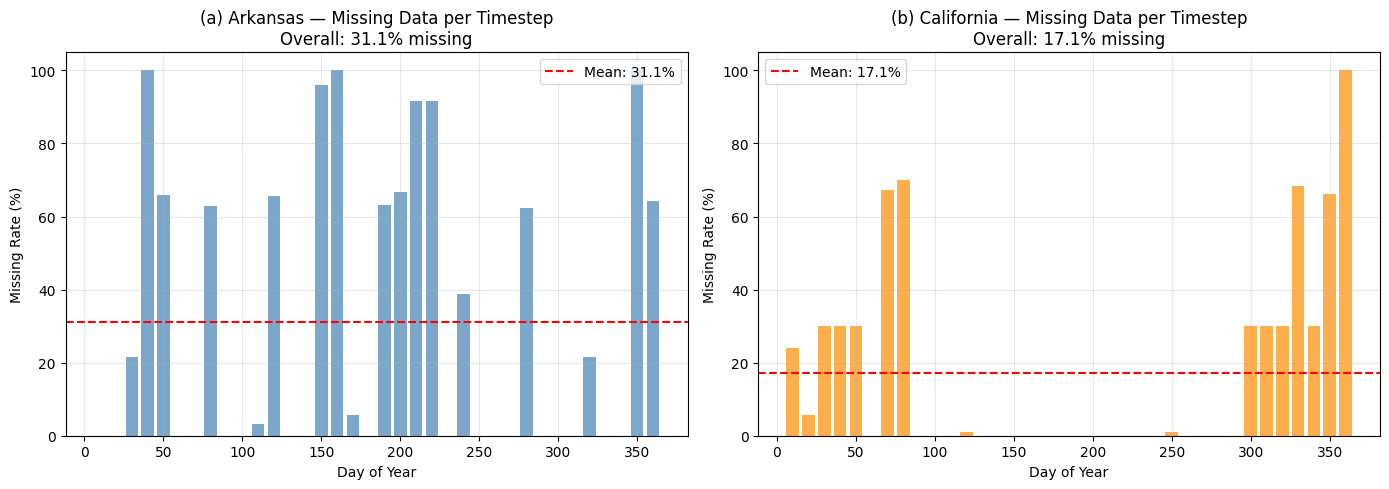

Key findings:
  Arkansas completely clouded timesteps: 3 out of 36
  California completely clouded timesteps: 1 out of 36
  Arkansas clear timesteps (0% missing): 0 out of 36
  California clear timesteps (0% missing): 0 out of 36


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

doy = np.arange(1, 37) * 10

# Arkansas
axes[0].bar(doy, mask_ark.mean(axis=0) * 100,
            color='steelblue', width=8, alpha=0.7)
axes[0].set_xlabel('Day of Year')
axes[0].set_ylabel('Missing Rate (%)')
axes[0].set_title('(a) Arkansas — Missing Data per Timestep\n'
                  f'Overall: {mask_ark.mean()*100:.1f}% missing')
axes[0].set_ylim(0, 105)
axes[0].axhline(y=mask_ark.mean()*100, color='red',
                linestyle='--', label=f'Mean: {mask_ark.mean()*100:.1f}%')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# California
axes[1].bar(doy, mask_cal.mean(axis=0) * 100,
            color='darkorange', width=8, alpha=0.7)
axes[1].set_xlabel('Day of Year')
axes[1].set_ylabel('Missing Rate (%)')
axes[1].set_title('(b) California — Missing Data per Timestep\n'
                  f'Overall: {mask_cal.mean()*100:.1f}% missing')
axes[1].set_ylim(0, 105)
axes[1].axhline(y=mask_cal.mean()*100, color='red',
                linestyle='--', label=f'Mean: {mask_cal.mean()*100:.1f}%')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('missing_data_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Key findings:")
print(f"  Arkansas completely clouded timesteps: "
      f"{(mask_ark.mean(axis=0)==1).sum()} out of 36")
print(f"  California completely clouded timesteps: "
      f"{(mask_cal.mean(axis=0)==1).sum()} out of 36")
print(f"  Arkansas clear timesteps (0% missing): "
      f"{(mask_ark.mean(axis=0)==0).sum()} out of 36")
print(f"  California clear timesteps (0% missing): "
      f"{(mask_cal.mean(axis=0)==0).sum()} out of 36")

# **PART 2 CREATING MODEL**

**Split train val test**

In [ ]:
# SESSION STARTUP — RUN THIS FIRST
# Every new session
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from huggingface_hub import hf_hub_download

REPO_ID = "inessal/CropMappingSentinel2"
DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# 1. LOAD RAW DATA
print("\nLoading data from HuggingFace...")
X_ark    = np.load(hf_hub_download(REPO_ID, "Arkansas_X .npy",       repo_type="dataset"))
mask_ark = np.load(hf_hub_download(REPO_ID, "Arkansas_mask.npy",    repo_type="dataset"))
y_ark    = np.load(hf_hub_download(REPO_ID, "Arkansas_y.npy",       repo_type="dataset"))
X_cal    = np.load(hf_hub_download(REPO_ID, "California_X.npy",     repo_type="dataset"))
mask_cal = np.load(hf_hub_download(REPO_ID, "California_mask.npy",  repo_type="dataset"))
y_cal    = np.load(hf_hub_download(REPO_ID, "California_y.npy",     repo_type="dataset"))
print("Data loaded")

# 2. NORMALIZE
X_ark = X_ark / 10000.0
X_cal = X_cal / 10000.0
print("Normalized")

# 3. RESHAPE TO (N, 36, 10)
X_ark = X_ark.reshape(-1, 36, 10)
X_cal = X_cal.reshape(-1, 36, 10)

# 4. STRATIFIED SPLIT
def stratified_split(X, mask, y, n_train=240, n_val=60, seed=42):
    np.random.seed(seed)
    classes = np.unique(y)
    train_idx, val_idx, test_idx = [], [], []
    for cls in classes:
        cls_idx = np.where(y == cls)[0]
        np.random.shuffle(cls_idx)
        if len(cls_idx) < n_train + n_val:
            n_tr = int(len(cls_idx) * 0.8)
            n_vl = len(cls_idx) - n_tr
            train_idx.extend(cls_idx[:n_tr].tolist())
            val_idx.extend(cls_idx[n_tr:n_tr+n_vl].tolist())
        else:
            train_idx.extend(cls_idx[:n_train].tolist())
            val_idx.extend(cls_idx[n_train:n_train+n_val].tolist())
            test_idx.extend(cls_idx[n_train+n_val:].tolist())
    np.random.shuffle(train_idx)
    np.random.shuffle(val_idx)
    np.random.shuffle(test_idx)
    return (X[train_idx],    mask[train_idx],    y[train_idx],
            X[val_idx],      mask[val_idx],      y[val_idx],
            X[test_idx],     mask[test_idx],     y[test_idx])

(X_ark_train, mask_ark_train, y_ark_train,
 X_ark_val,   mask_ark_val,   y_ark_val,
 X_ark_test,  mask_ark_test,  y_ark_test) = stratified_split(X_ark, mask_ark, y_ark)

(X_cal_train, mask_cal_train, y_cal_train,
 X_cal_val,   mask_cal_val,   y_cal_val,
 X_cal_test,  mask_cal_test,  y_cal_test) = stratified_split(X_cal, mask_cal, y_cal)

print("✅ Split done")
print(f"   Arkansas  — Train: {len(y_ark_train)}, Val: {len(y_ark_val)}, Test: {len(y_ark_test)}")
print(f"   California — Train: {len(y_cal_train)}, Val: {len(y_cal_val)}, Test: {len(y_cal_test)}")

# 5. PYTORCH DATASET + DATALOADER
class CropDataset(Dataset):
    def __init__(self, X, mask, y, label_map):
        self.X    = torch.tensor(X,    dtype=torch.float32)
        self.mask = torch.tensor(mask, dtype=torch.float32)
        self.y    = torch.tensor(
                        np.array([label_map[int(c)] for c in y]),
                        dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.mask[idx], self.y[idx]

ark_label_map  = {1:0, 2:1, 3:2, 5:3, 99:4}
cal_label_map  = {69:0, 3:1, 36:2, 75:3, 204:4, 99:5}
ark_class_names = ['Corn', 'Cotton', 'Rice', 'Soybeans', 'Others']
cal_class_names = ['Grapes', 'Rice', 'Alfalfa', 'Almonds', 'Pistachios', 'Others']

BATCH_SIZE = 32

ark_train_loader = DataLoader(CropDataset(X_ark_train, mask_ark_train, y_ark_train, ark_label_map), batch_size=BATCH_SIZE, shuffle=True)
ark_val_loader   = DataLoader(CropDataset(X_ark_val,   mask_ark_val,   y_ark_val,   ark_label_map), batch_size=BATCH_SIZE, shuffle=False)
ark_test_loader  = DataLoader(CropDataset(X_ark_test,  mask_ark_test,  y_ark_test,  ark_label_map), batch_size=BATCH_SIZE, shuffle=False)

cal_train_loader = DataLoader(CropDataset(X_cal_train, mask_cal_train, y_cal_train, cal_label_map), batch_size=BATCH_SIZE, shuffle=True)
cal_val_loader   = DataLoader(CropDataset(X_cal_val,   mask_cal_val,   y_cal_val,   cal_label_map), batch_size=BATCH_SIZE, shuffle=False)
cal_test_loader  = DataLoader(CropDataset(X_cal_test,  mask_cal_test,  y_cal_test,  cal_label_map), batch_size=BATCH_SIZE, shuffle=False)

print("✅ DataLoaders ready")

# Verify batch
X_b, mask_b, y_b = next(iter(ark_train_loader))
print(f"\nSample batch — X: {X_b.shape}, mask: {mask_b.shape}, y: {y_b.shape}")
print(f"Device: {DEVICE}")
print("\nReady to build and train MCTNet!")

Using device: cuda

Loading data from HuggingFace...
✅ Data loaded
✅ Normalized
✅ Split done
   Arkansas  — Train: 1200, Val: 300, Test: 8500
   California — Train: 1440, Val: 360, Test: 8200
✅ DataLoaders ready

Sample batch — X: torch.Size([32, 36, 10]), mask: torch.Size([32, 36]), y: torch.Size([32])
Device: cuda

🚀 Ready to build and train MCTNet!


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ALPE MODULE
class ALPE(nn.Module):
    def __init__(self, d=10, T=36):
        super().__init__()
        pe = torch.zeros(T, d)
        pos = torch.arange(T).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d, 2).float() * (-np.log(10000) / d))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe)
        self.conv = nn.Conv1d(d, d, kernel_size=3, padding=1)
        self.eca  = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Conv1d(d, d, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x, mask):
        pe    = self.pe.unsqueeze(0).expand(x.size(0), -1, -1)
        pe    = pe * (1 - mask.unsqueeze(-1))
        pe    = pe.transpose(1, 2)
        pe    = self.conv(pe)
        scale = self.eca(pe)
        return (pe * scale).transpose(1, 2)


# CNN BLOCK
class CNNBlock(nn.Module):
    def __init__(self, d, k=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(d, d, k, padding=k//2),
            nn.BatchNorm1d(d),
            nn.Conv1d(d, d, k, padding=k//2),
            nn.BatchNorm1d(d)
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        xt = x.transpose(1, 2)
        return self.relu(self.net(xt) + xt).transpose(1, 2)


# CTFUSION MODULE
class CTFusion(nn.Module):
    def __init__(self, d, n_head, k=3, use_alpe=False):
        super().__init__()
        self.use_alpe = use_alpe
        if use_alpe:
            self.alpe = ALPE(d=d)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = d,
            nhead           = n_head,
            dim_feedforward = d * 8,
            batch_first     = True,
            dropout         = 0.1
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.cnn  = CNNBlock(d, k)
        self.pool = nn.MaxPool1d(kernel_size=2)

    def forward(self, x, mask=None):
        if self.use_alpe and mask is not None:
            pos = self.alpe(x, mask)
            xt  = x + pos
        else:
            xt = x
        t_out = self.transformer(xt)
        c_out = self.cnn(x)
        fused = torch.cat([t_out, c_out], dim=-1)
        out   = self.pool(fused.transpose(1, 2))
        return out.transpose(1, 2)


# FULL MCTNET
class MCTNet(nn.Module):
    def __init__(self, n_bands=10, n_stages=3,
                 n_head=5, kernel_size=3, n_classes=5):
        super().__init__()
        self.stages = nn.ModuleList()
        in_d = n_bands

        for i in range(n_stages):
            self.stages.append(
                CTFusion(
                    d        = in_d,
                    n_head   = n_head,
                    k        = kernel_size,
                    use_alpe = (i == 0)
                )
            )
            in_d *= 2

        self.classifier = nn.Linear(in_d, n_classes)

    def forward(self, x, mask=None):
        for stage in self.stages:
            x = stage(x, mask)
        x = x.max(dim=1).values
        return self.classifier(x)


# VERIFY
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

model_ark = MCTNet(n_classes=5).to(device)
model_cal = MCTNet(n_classes=6).to(device)

x_test    = torch.randn(32, 36, 10).to(device)
mask_test = torch.zeros(32, 36).to(device)
mask_test[:, 5:8] = 1

out_ark = model_ark(x_test, mask_test)
out_cal = model_cal(x_test, mask_test)

print(f"Output (Arkansas):    {out_ark.shape}")
print(f"Output (California):  {out_cal.shape}")
print(f"Parameters:           {sum(p.numel() for p in model_ark.parameters()):,}")
print(f"Paper:                55,059")
print("\n✅ Model ready for training!")

Device: cuda
Output (Arkansas):    torch.Size([32, 5])
Output (California):  torch.Size([32, 6])
Parameters:           57,035
Paper:                55,059

✅ Model ready for training!


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ===============================
# 1. REDEFINE THE MODEL ARCHITECTURE
# (must match exactly what you trained)
# ===============================
import math

class ALPE(nn.Module):
    def __init__(self, d=10, T=36):
        super().__init__()
        pe = torch.zeros(T, d)
        pos = torch.arange(T).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d, 2).float() * (-np.log(10000) / d))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe)
        self.conv = nn.Conv1d(d, d, kernel_size=3, padding=1)
        self.eca  = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Conv1d(d, d, kernel_size=1),
            nn.Sigmoid()
        )
    def forward(self, x, mask):
        pe    = self.pe.unsqueeze(0).expand(x.size(0), -1, -1)
        pe    = pe * (1 - mask.unsqueeze(-1))
        pe    = pe.transpose(1, 2)
        pe    = self.conv(pe)
        scale = self.eca(pe)
        return (pe * scale).transpose(1, 2)

class CNNBlock(nn.Module):
    def __init__(self, d, k=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(d, d, k, padding=k//2),
            nn.BatchNorm1d(d),
            nn.Conv1d(d, d, k, padding=k//2),
            nn.BatchNorm1d(d)
        )
        self.relu = nn.ReLU()
    def forward(self, x):
        xt = x.transpose(1, 2)
        return self.relu(self.net(xt) + xt).transpose(1, 2)

class CTFusion(nn.Module):
    def __init__(self, d, n_head, k=3, use_alpe=False):
        super().__init__()
        self.use_alpe = use_alpe
        if use_alpe:
            self.alpe = ALPE(d=d)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = d,
            nhead           = n_head,
            dim_feedforward = d * 8,
            batch_first     = True,
            dropout         = 0.1
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.cnn  = CNNBlock(d, k)
        self.pool = nn.MaxPool1d(kernel_size=2)
    def forward(self, x, mask=None):
        if self.use_alpe and mask is not None:
            pos = self.alpe(x, mask)
            xt  = x + pos
        else:
            xt = x
        t_out = self.transformer(xt)
        c_out = self.cnn(x)
        fused = torch.cat([t_out, c_out], dim=-1)
        out   = self.pool(fused.transpose(1, 2))
        return out.transpose(1, 2)

class MCTNet(nn.Module):
    def __init__(self, n_bands=10, n_stages=3,
                 n_head=5, kernel_size=3, n_classes=5):
        super().__init__()
        self.stages = nn.ModuleList()
        in_d = n_bands
        for i in range(n_stages):
            self.stages.append(
                CTFusion(in_d, n_head, kernel_size, use_alpe=(i == 0))
            )
            in_d *= 2
        self.classifier = nn.Linear(in_d, n_classes)
    def forward(self, x, mask=None):
        for stage in self.stages:
            x = stage(x, mask)
        x = x.max(dim=1).values
        return self.classifier(x)

print("✅ Model architecture defined")

# ===============================
# 2. LOAD SAVED WEIGHTS FROM LAPTOP
# ===============================
from google.colab import files

print("\nUpload mctnet_arkansas.pth and mctnet_california.pth...")
uploaded = files.upload()  # opens file picker → select both .pth files

# ===============================
# 3. LOAD MODELS
# ===============================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nDevice: {device}")

# Arkansas
model_ark = MCTNet(n_classes=5).to(device)
model_ark.load_state_dict(torch.load('mctnet_arkansas.pth',
                                      map_location=device))
model_ark.eval()
print("✅ Arkansas model loaded")

# California
model_cal = MCTNet(n_classes=6).to(device)
model_cal.load_state_dict(torch.load('mctnet_california.pth',
                                      map_location=device))
model_cal.eval()
print("✅ California model loaded")

# ===============================
# 4. LOAD DATA + PREPARE TEST SETS
# ===============================
from huggingface_hub import hf_hub_download
from torch.utils.data import Dataset, DataLoader

REPO_ID = "inessal/CropMappingSentinel2"

print("\nLoading data from HuggingFace...")
X_ark    = np.load(hf_hub_download(REPO_ID, "Arkansas_X .npy",    repo_type="dataset"))
mask_ark = np.load(hf_hub_download(REPO_ID, "Arkansas_mask.npy", repo_type="dataset"))
y_ark    = np.load(hf_hub_download(REPO_ID, "Arkansas_y.npy",    repo_type="dataset"))
X_cal    = np.load(hf_hub_download(REPO_ID, "California_X.npy",    repo_type="dataset"))
mask_cal = np.load(hf_hub_download(REPO_ID, "California_mask.npy", repo_type="dataset"))
y_cal    = np.load(hf_hub_download(REPO_ID, "California_y.npy",    repo_type="dataset"))
print("✅ Data loaded")

# Normalize + reshape
X_ark = (X_ark / 10000.0).reshape(-1, 36, 10)
X_cal = (X_cal / 10000.0).reshape(-1, 36, 10)

# Split
def stratified_split(X, mask, y, n_train=240, n_val=60, seed=42):
    np.random.seed(seed)
    classes = np.unique(y)
    train_idx, val_idx, test_idx = [], [], []
    for cls in classes:
        cls_idx = np.where(y == cls)[0]
        np.random.shuffle(cls_idx)
        if len(cls_idx) < n_train + n_val:
            n_tr = int(len(cls_idx) * 0.8)
            n_vl = len(cls_idx) - n_tr
            train_idx.extend(cls_idx[:n_tr].tolist())
            val_idx.extend(cls_idx[n_tr:n_tr+n_vl].tolist())
        else:
            train_idx.extend(cls_idx[:n_train].tolist())
            val_idx.extend(cls_idx[n_train:n_train+n_val].tolist())
            test_idx.extend(cls_idx[n_train+n_val:].tolist())
    np.random.shuffle(test_idx)
    return (X[train_idx],  mask[train_idx],  y[train_idx],
            X[val_idx],    mask[val_idx],    y[val_idx],
            X[test_idx],   mask[test_idx],   y[test_idx])

(X_ark_train, mask_ark_train, y_ark_train,
 X_ark_val,   mask_ark_val,   y_ark_val,
 X_ark_test,  mask_ark_test,  y_ark_test) = stratified_split(X_ark, mask_ark, y_ark)

(X_cal_train, mask_cal_train, y_cal_train,
 X_cal_val,   mask_cal_val,   y_cal_val,
 X_cal_test,  mask_cal_test,  y_cal_test) = stratified_split(X_cal, mask_cal, y_cal)

# Dataset class
class CropDataset(Dataset):
    def __init__(self, X, mask, y, label_map):
        self.X    = torch.tensor(X,    dtype=torch.float32)
        self.mask = torch.tensor(mask, dtype=torch.float32)
        self.y    = torch.tensor(
                        np.array([label_map[int(c)] for c in y]),
                        dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.mask[idx], self.y[idx]

ark_label_map = {1:0, 2:1, 3:2, 5:3, 99:4}
cal_label_map = {69:0, 3:1, 36:2, 75:3, 204:4, 99:5}

ark_test_loader = DataLoader(
    CropDataset(X_ark_test, mask_ark_test, y_ark_test, ark_label_map),
    batch_size=32, shuffle=False)

cal_test_loader = DataLoader(
    CropDataset(X_cal_test, mask_cal_test, y_cal_test, cal_label_map),
    batch_size=32, shuffle=False)

print("✅ Test loaders ready")
print(f"\nArkansas test: {len(y_ark_test)} samples")
print(f"California test: {len(y_cal_test)} samples")
print("\n🚀 Ready for evaluation!")

✅ Model architecture defined

Upload mctnet_arkansas.pth and mctnet_california.pth...


Saving mctnet_arkansas.pth to mctnet_arkansas.pth
Saving mctnet_california.pth to mctnet_california.pth

Device: cuda
✅ Arkansas model loaded
✅ California model loaded

Loading data from HuggingFace...
✅ Data loaded
✅ Test loaders ready

Arkansas test: 8500 samples
California test: 8200 samples

🚀 Ready for evaluation!



Training MCTNet on Arkansas
  lr=0.001, weight_decay=0.0001, patience=20
 Epoch | Train Loss |  Train OA |  Val Loss |  Val OA | Val Kappa |  Val F1
----------------------------------------------------------------------
     1 |     0.9536 |    0.6942 |    0.9835 |  0.6233 |    0.5292 |  0.5648 ← best
    10 |     0.0939 |    0.9717 |    0.2183 |  0.9333 |    0.9167 |  0.9344
    20 |     0.0459 |    0.9850 |    0.1952 |  0.9433 |    0.9292 |  0.9445
    30 |     0.0369 |    0.9908 |    0.1653 |  0.9467 |    0.9333 |  0.9470
    40 |     0.0052 |    0.9992 |    0.1775 |  0.9500 |    0.9375 |  0.9498

⏹ Early stopping at epoch 44 (no improvement for 20 epochs)

✅ Best model at epoch 24 with Val Kappa = 0.9500

FINAL TEST RESULTS — Arkansas
  OA:    0.9632   (paper: 0.968)
  Kappa: 0.9437   (paper: 0.951)
  F1:    0.9320   (paper: 0.933)


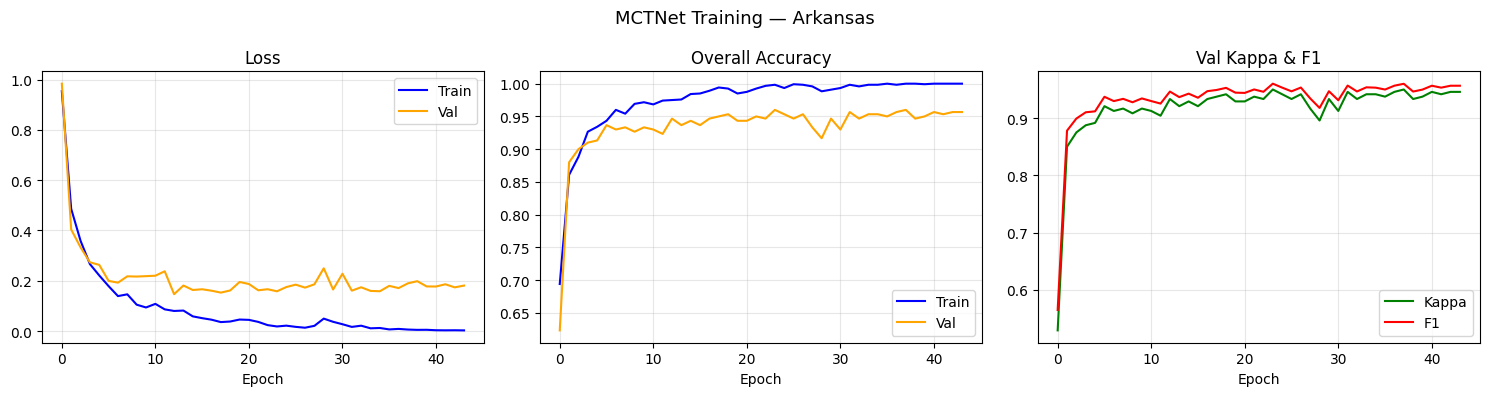


Training MCTNet on California
  lr=0.001, weight_decay=0.0001, patience=20
 Epoch | Train Loss |  Train OA |  Val Loss |  Val OA | Val Kappa |  Val F1
----------------------------------------------------------------------
     1 |     0.8661 |    0.7278 |    0.7686 |  0.7111 |    0.6533 |  0.6571 ← best
    10 |     0.2584 |    0.9083 |    0.3625 |  0.8472 |    0.8167 |  0.8464
    20 |     0.1762 |    0.9319 |    0.3915 |  0.8694 |    0.8433 |  0.8678
    30 |     0.1064 |    0.9604 |    0.4183 |  0.8583 |    0.8300 |  0.8559
    40 |     0.0637 |    0.9806 |    0.4806 |  0.8611 |    0.8333 |  0.8600
    50 |     0.0577 |    0.9833 |    0.5990 |  0.8611 |    0.8333 |  0.8589

⏹ Early stopping at epoch 53 (no improvement for 20 epochs)

✅ Best model at epoch 33 with Val Kappa = 0.8733

FINAL TEST RESULTS — California
  OA:    0.8691   (paper: 0.852)
  Kappa: 0.8276   (paper: 0.806)
  F1:    0.8692   (paper: 0.829)


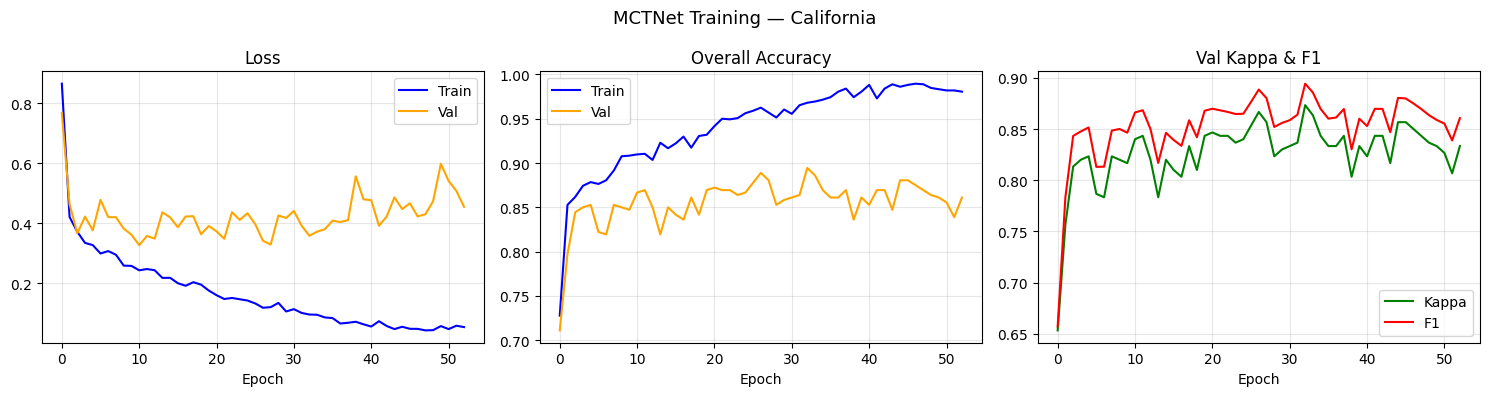

In [ ]:
import torch
import torch.nn as nn
from torch.optim import Adam
from sklearn.metrics import cohen_kappa_score, f1_score
import numpy as np
import matplotlib.pyplot as plt

# 1. TRAINING FUNCTION
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for X_batch, mask_batch, y_batch in loader:
        X_batch    = X_batch.to(device)
        mask_batch = mask_batch.to(device)
        y_batch    = y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch, mask_batch)
        loss    = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(y_batch)
        preds       = outputs.argmax(dim=1)
        correct    += (preds == y_batch).sum().item()
        total      += len(y_batch)

    return total_loss / total, correct / total


# 2. EVALUATION FUNCTION
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X_batch, mask_batch, y_batch in loader:
            X_batch    = X_batch.to(device)
            mask_batch = mask_batch.to(device)
            y_batch    = y_batch.to(device)

            outputs = model(X_batch, mask_batch)
            loss    = criterion(outputs, y_batch)

            total_loss += loss.item() * len(y_batch)
            preds       = outputs.argmax(dim=1)
            correct    += (preds == y_batch).sum().item()
            total      += len(y_batch)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / total
    oa       = correct / total
    kappa    = cohen_kappa_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds,
                        average='macro', zero_division=0)

    return avg_loss, oa, kappa, f1


# 3. IMPROVED TRAINING LOOP
# - weight_decay in Adam (L2 regularization)
# - early stopping on val kappa
def train_model(model, train_loader, val_loader,
                n_epochs=200, lr=0.001,
                weight_decay=1e-4,   # L2 regularization
                patience=20,          # early stopping patience
                device='cuda',
                state_name='Arkansas'):

    criterion = nn.CrossEntropyLoss()

    optimizer = Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Best model tracking
    best_val_kappa  = 0.0
    best_epoch      = 0
    best_weights    = None
    epochs_no_improve = 0  # early stopping counter

    history = {
        'train_loss': [], 'val_loss':  [],
        'train_oa':   [], 'val_oa':    [],
        'val_kappa':  [], 'val_f1':    []
    }

    print(f"\n{'='*70}")
    print(f"Training MCTNet on {state_name}")
    print(f"  lr={lr}, weight_decay={weight_decay}, patience={patience}")
    print(f"{'='*70}")
    print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train OA':>9} | "
          f"{'Val Loss':>9} | {'Val OA':>7} | {'Val Kappa':>9} | {'Val F1':>7}")
    print(f"{'-'*70}")

    for epoch in range(1, n_epochs + 1):

        train_loss, train_oa = train_one_epoch(
            model, train_loader, optimizer, criterion, device)

        val_loss, val_oa, val_kappa, val_f1 = evaluate(
            model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_oa'].append(train_oa)
        history['val_oa'].append(val_oa)
        history['val_kappa'].append(val_kappa)
        history['val_f1'].append(val_f1)

        # Save best model
        if val_kappa > best_val_kappa:
            best_val_kappa    = val_kappa
            best_epoch        = epoch
            best_weights      = {k: v.cpu().clone()
                                 for k, v in model.state_dict().items()}
            epochs_no_improve = 0  # reset counter
        else:
            epochs_no_improve += 1  # increment counter

        # Print progress
        if epoch % 10 == 0 or epoch == 1:
            marker = ' ← best' if epoch == best_epoch else ''
            print(f"{epoch:>6} | {train_loss:>10.4f} | {train_oa:>9.4f} | "
                  f"{val_loss:>9.4f} | {val_oa:>7.4f} | "
                  f"{val_kappa:>9.4f} | {val_f1:>7.4f}{marker}")

        # Early stopping check
        if epochs_no_improve >= patience:
            print(f"\n⏹ Early stopping at epoch {epoch} "
                  f"(no improvement for {patience} epochs)")
            break

    print(f"\n✅ Best model at epoch {best_epoch} "
          f"with Val Kappa = {best_val_kappa:.4f}")

    # Restore best weights
    model.load_state_dict({k: v.to(device)
                           for k, v in best_weights.items()})

    return model, history


# 4. PLOT FUNCTION
def plot_history(history, state_name):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(history['train_loss'], label='Train', color='blue')
    axes[0].plot(history['val_loss'],   label='Val',   color='orange')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history['train_oa'], label='Train', color='blue')
    axes[1].plot(history['val_oa'],   label='Val',   color='orange')
    axes[1].set_title('Overall Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(history['val_kappa'], label='Kappa', color='green')
    axes[2].plot(history['val_f1'],    label='F1',    color='red')
    axes[2].set_title('Val Kappa & F1')
    axes[2].set_xlabel('Epoch')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.suptitle(f'MCTNet Training — {state_name}', fontsize=13)
    plt.tight_layout()
    plt.show()


# 5. TRAIN ARKANSAS
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_ark = MCTNet(n_classes=5).to(device)

model_ark, history_ark = train_model(
    model        = model_ark,
    train_loader = ark_train_loader,
    val_loader   = ark_val_loader,
    n_epochs     = 200,
    lr           = 0.001,
    weight_decay = 1e-4,
    patience     = 20,
    device       = device,
    state_name   = 'Arkansas'
)

# Test
print("\n" + "="*60)
print("FINAL TEST RESULTS — Arkansas")
print("="*60)
_, test_oa, test_kappa, test_f1 = evaluate(
    model_ark, ark_test_loader, nn.CrossEntropyLoss(), device)
print(f"  OA:    {test_oa:.4f}   (paper: 0.968)")
print(f"  Kappa: {test_kappa:.4f}   (paper: 0.951)")
print(f"  F1:    {test_f1:.4f}   (paper: 0.933)")

plot_history(history_ark, 'Arkansas')

# 6. TRAIN CALIFORNIA
model_cal = MCTNet(n_classes=6).to(device)

model_cal, history_cal = train_model(
    model        = model_cal,
    train_loader = cal_train_loader,
    val_loader   = cal_val_loader,
    n_epochs     = 200,
    lr           = 0.001,
    weight_decay = 1e-4,
    patience     = 20,
    device       = device,
    state_name   = 'California'
)

# Test
print("\n" + "="*60)
print("FINAL TEST RESULTS — California")
print("="*60)
_, test_oa, test_kappa, test_f1 = evaluate(
    model_cal, cal_test_loader, nn.CrossEntropyLoss(), device)
print(f"  OA:    {test_oa:.4f}   (paper: 0.852)")
print(f"  Kappa: {test_kappa:.4f}   (paper: 0.806)")
print(f"  F1:    {test_f1:.4f}   (paper: 0.829)")

plot_history(history_cal, 'California')

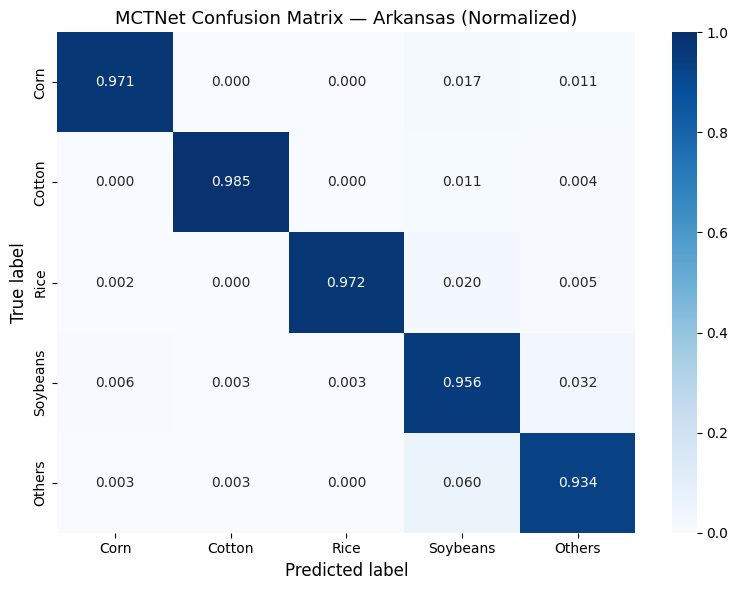


Per-Class Results — Arkansas
              precision    recall  f1-score   support

        Corn     0.9730    0.9714    0.9722      1222
      Cotton     0.9722    0.9848    0.9785       462
        Rice     0.9942    0.9722    0.9831      2123
    Soybeans     0.9794    0.9564    0.9677      4377
      Others     0.6385    0.9335    0.7584       316

    accuracy                         0.9632      8500
   macro avg     0.9115    0.9637    0.9320      8500
weighted avg     0.9691    0.9632    0.9650      8500

  OA:    0.9632   (paper: 0.968)
  Kappa: 0.9437   (paper: 0.951)
  F1:    0.9320   (paper: 0.933)


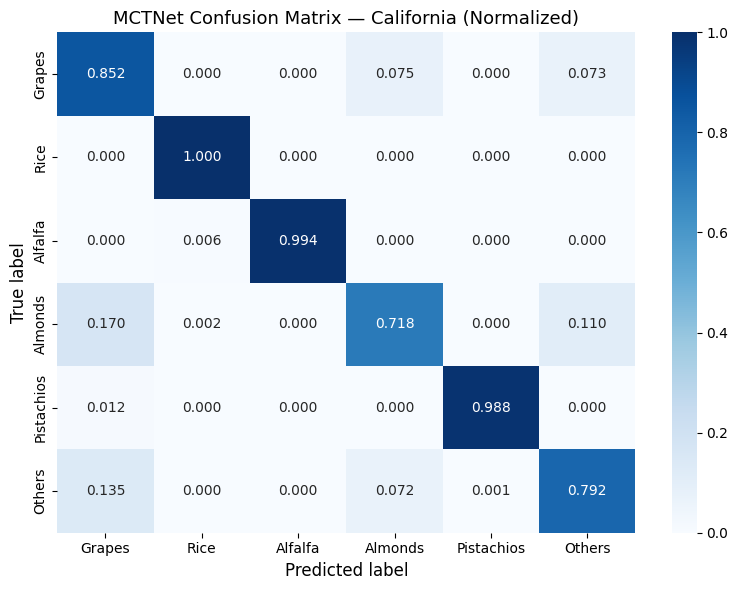


Per-Class Results — California
              precision    recall  f1-score   support

      Grapes     0.7422    0.8518    0.7932      1754
        Rice     0.9971    1.0000    0.9986      1737
     Alfalfa     1.0000    0.9941    0.9970       674
     Almonds     0.4880    0.7184    0.5812       483
  Pistachios     0.9882    0.9882    0.9882       340
      Others     0.9336    0.7917    0.8568      3212

    accuracy                         0.8691      8200
   macro avg     0.8582    0.8907    0.8692      8200
weighted avg     0.8876    0.8691    0.8740      8200

  OA:    0.8691   (paper: 0.852)
  Kappa: 0.8276   (paper: 0.806)
  F1:    0.8692   (paper: 0.829)


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. GET ALL PREDICTIONS
def get_predictions(model, loader, device):
    model.eval()
    all_preds  = []
    all_labels = []
    all_probs  = []

    with torch.no_grad():
        for X_batch, mask_batch, y_batch in loader:
            X_batch    = X_batch.to(device)
            mask_batch = mask_batch.to(device)

            outputs = model(X_batch, mask_batch)  # (batch, n_classes)
            probs   = torch.softmax(outputs, dim=1)
            preds   = outputs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.numpy())
            all_probs.extend(probs.cpu().numpy())

    return (np.array(all_labels),
            np.array(all_preds),
            np.array(all_probs))


# 2. CONFUSION MATRIX PLOT

def plot_confusion_matrix(labels, preds, class_names, title):
    cm = confusion_matrix(labels, preds)

    # Normalize per row (true class)
    cm_norm = cm.astype(float)
    for i in range(len(cm)):
        row_sum = cm[i].sum()
        if row_sum > 0:
            cm_norm[i] = cm[i] / row_sum

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm_norm,
        annot      = True,
        fmt        = '.3f',
        cmap       = 'Blues',
        xticklabels = class_names,
        yticklabels = class_names,
        vmin = 0, vmax = 1,
        ax   = ax
    )
    ax.set_xlabel('Predicted label', fontsize=12)
    ax.set_ylabel('True label',      fontsize=12)
    ax.set_title(title,              fontsize=13)
    plt.tight_layout()
    plt.show()

    return cm, cm_norm


# 3. PER CLASS REPORT
def print_classification_report(labels, preds, class_names, state_name):
    print(f"\n{'='*60}")
    print(f"Per-Class Results — {state_name}")
    print(f"{'='*60}")
    print(classification_report(
        labels, preds,
        target_names = class_names,
        digits       = 4
    ))


# 4. ARKANSAS EVALUATION
ark_class_names = ['Corn', 'Cotton', 'Rice', 'Soybeans', 'Others']

y_true_ark, y_pred_ark, y_probs_ark = get_predictions(
    model_ark, ark_test_loader, device)

# Confusion matrix
cm_ark, cm_norm_ark = plot_confusion_matrix(
    y_true_ark, y_pred_ark,
    class_names = ark_class_names,
    title       = 'MCTNet Confusion Matrix — Arkansas (Normalized)'
)

# Per class report
print_classification_report(
    y_true_ark, y_pred_ark,
    class_names = ark_class_names,
    state_name  = 'Arkansas'
)

# Overall metrics
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score
oa    = accuracy_score(y_true_ark, y_pred_ark)
kappa = cohen_kappa_score(y_true_ark, y_pred_ark)
f1    = f1_score(y_true_ark, y_pred_ark, average='macro', zero_division=0)

print(f"  OA:    {oa:.4f}   (paper: 0.968)")
print(f"  Kappa: {kappa:.4f}   (paper: 0.951)")
print(f"  F1:    {f1:.4f}   (paper: 0.933)")


# 5. CALIFORNIA EVALUATION
cal_class_names = ['Grapes', 'Rice', 'Alfalfa', 'Almonds', 'Pistachios', 'Others']

y_true_cal, y_pred_cal, y_probs_cal = get_predictions(
    model_cal, cal_test_loader, device)

# Confusion matrix
cm_cal, cm_norm_cal = plot_confusion_matrix(
    y_true_cal, y_pred_cal,
    class_names = cal_class_names,
    title       = 'MCTNet Confusion Matrix — California (Normalized)'
)

# Per class report
print_classification_report(
    y_true_cal, y_pred_cal,
    class_names = cal_class_names,
    state_name  = 'California'
)

# Overall metrics
oa    = accuracy_score(y_true_cal, y_pred_cal)
kappa = cohen_kappa_score(y_true_cal, y_pred_cal)
f1    = f1_score(y_true_cal, y_pred_cal, average='macro', zero_division=0)

print(f"  OA:    {oa:.4f}   (paper: 0.852)")
print(f"  Kappa: {kappa:.4f}   (paper: 0.806)")
print(f"  F1:    {f1:.4f}   (paper: 0.829)")